# Credit Risk Scoring & Loan Approval System

## 💼 Business Understanding

### Key business questions

- Which borrowers are likely to default?
- How can borrowers be grouped into risk levels?
- What approval threshold should be used?
- What financial tradeoffs exist between risky approvals and rejected customers?
- Which factors contribute most to default risk?

### Problem type

- Binary classification problem

### Target variable

- `0` → No serious financial distress
- `1` → Serious financial distress within two years

### Modeling goal

Predict the probability of borrower default risk.

In [1]:
# Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load training dataset
df = pd.read_csv(
    "/kaggle/input/competitions/GiveMeSomeCredit/cs-training.csv"
)

df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:
# Check dataset shape
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 150000
Columns: 12


In [4]:
# View column names
df.columns

Index(['Unnamed: 0', 'SeriousDlqin2yrs',
       'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

In [5]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [6]:
# Remove unnecessary column
df = df.drop(columns="Unnamed: 0")

df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


### Insights

- The dataset contains 150,000 borrower records and 12 columns.
- Most variables are numerical and related to credit usage, delinquency history, debt ratio, and borrowing behavior.
- The target variable is `SeriousDlqin2yrs`, which indicates whether a borrower experienced serious financial distress within two years.
- `MonthlyIncome` and `NumberOfDependents` contain missing values that will require preprocessing later.
- `Unnamed: 0` appears to be an index-like column and may not provide predictive value.

In [7]:
# Check target distribution
target_counts = df["SeriousDlqin2yrs"].value_counts()
target_percentages = (
    df["SeriousDlqin2yrs"]
    .value_counts(normalize=True) * 100
)

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages.round(2)
})

target_summary

,Count,Percentage
SeriousDlqin2yrs,,
0,139974,93.32
1,10026,6.68


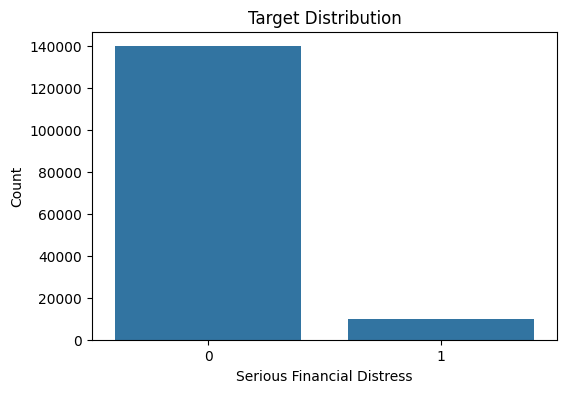

In [8]:
# Visualize target distribution
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="SeriousDlqin2yrs"
)

plt.title("Target Distribution")
plt.xlabel("Serious Financial Distress")
plt.ylabel("Count")

plt.show()

### Insights

- The dataset is highly imbalanced.
- About 93.32% of borrowers did not experience serious financial distress.
- Only 6.68% belong to the default/high-risk class.
- This imbalance makes accuracy less reliable as a standalone evaluation metric.
- Later stages will focus more on recall, precision, probability calibration, and threshold tuning.

## 📊 Exploratory Data Analysis

In [9]:
# Check missing values
missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": (
        missing_values / len(df) * 100
    ).round(2)
})

missing_summary.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage
MonthlyIncome,29731,19.82
NumberOfDependents,3924,2.62
SeriousDlqin2yrs,0,0.00
age,0,0.00
RevolvingUtilizationOfUnsecuredLines,0,0.00
DebtRatio,0,0.00
NumberOfTime30-59DaysPastDueNotWorse,0,0.00
NumberOfOpenCreditLinesAndLoans,0,0.00
NumberOfTimes90DaysLate,0,0.00
NumberRealEstateLoansOrLines,0,0.00


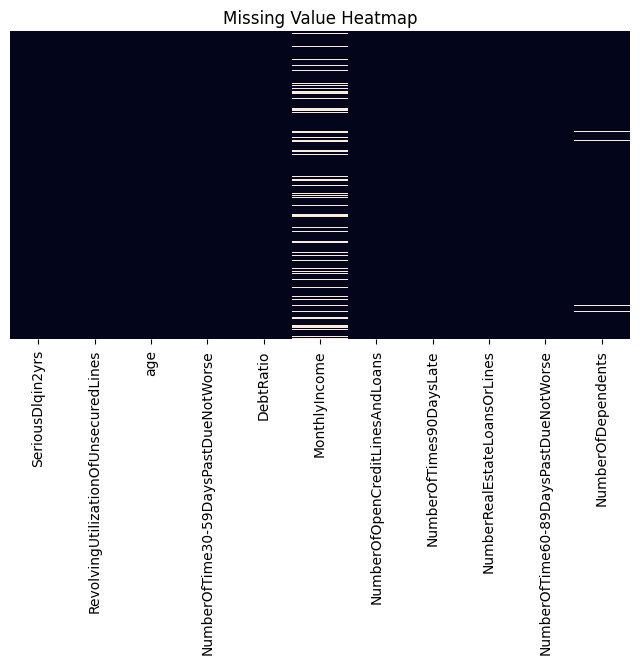

In [10]:
# Visualize missing values
plt.figure(figsize=(8, 4))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Value Heatmap")

plt.show()

### Insights

- `MonthlyIncome` has a significant amount of missing data, with nearly 20% of records missing income information.
- `NumberOfDependents` contains a smaller percentage of missing values.
- Most other financial and delinquency-related variables are complete.
- The missingness pattern appears concentrated rather than randomly spread across many variables.
- Since income is an important credit risk factor, handling missing income values carefully will be important during preprocessing and modeling.

In [11]:
# Display statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


In [12]:
#Check borrowers with age equal to 0
df[df["age"] == 0]

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
65695,0,1.0,0,1,0.436927,6000.0,6,0,2,0,2.0


In [13]:
# Check extreme revolving utilization values
df[
    df["RevolvingUtilizationOfUnsecuredLines"] > 5
][
    ["RevolvingUtilizationOfUnsecuredLines"]
].describe()

,RevolvingUtilizationOfUnsecuredLines
count,254.000000
mean,3381.930768
std,5051.880235
min,5.148736
25%,760.500000
50%,1899.000000
75%,3871.750000
max,50708.000000


In [14]:
# Check extreme debt ratio values
df[
    df["DebtRatio"] > 5
][
    ["DebtRatio"]
].describe()

,DebtRatio
count,29646.000000
mean,1784.589721
std,4296.240265
min,5.021978
25%,305.000000
50%,1291.000000
75%,2466.000000
max,329664.000000


In [15]:
# Check unusual delinquency values
df[
    (
        df["NumberOfTime30-59DaysPastDueNotWorse"] == 98
    ) |
    (
        df["NumberOfTime60-89DaysPastDueNotWorse"] == 98
    ) |
    (
        df["NumberOfTimes90DaysLate"] == 98
    )
]

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1733,1,1.0,27,98,0.0,2700.0,0,98,0,98,0.0
2286,0,1.0,22,98,0.0,NaN,0,98,0,98,0.0
3884,0,1.0,38,98,12.0,NaN,0,98,0,98,0.0
4417,0,1.0,21,98,0.0,0.0,0,98,0,98,0.0
4705,0,1.0,21,98,0.0,2000.0,0,98,0,98,0.0
...,...,...,...,...,...,...,...,...,...,...,...
147774,1,1.0,68,98,255.0,NaN,0,98,0,98,0.0
149153,1,1.0,24,98,54.0,NaN,0,98,0,98,0.0
149239,0,1.0,26,98,0.0,2000.0,0,98,0,98,0.0
149439,1,1.0,34,98,9.0,NaN,0,98,0,98,0.0


### Data Quality Observations

- Several variables contain unrealistic or highly suspicious values.
- One borrower has an age value of `0`, which is likely a data quality issue.
- `RevolvingUtilizationOfUnsecuredLines` contains extremely large values far beyond normal utilization ranges.
- `DebtRatio` also contains unusually large observations, suggesting possible outliers or scaling inconsistencies.
- The delinquency-related variables contain repeated values of `98`, which appears abnormal and may represent placeholder or corrupted values rather than actual delinquency counts.
- These findings suggest that outlier handling and data quality checks will play an important role before modeling.

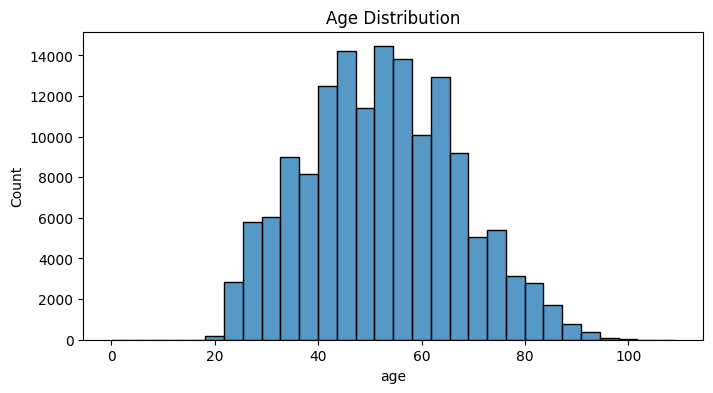

In [16]:
# Visualize age distribution
plt.figure(figsize=(8, 4))

sns.histplot(
    data=df,
    x="age",
    bins=30
)

plt.title("Age Distribution")

plt.show()

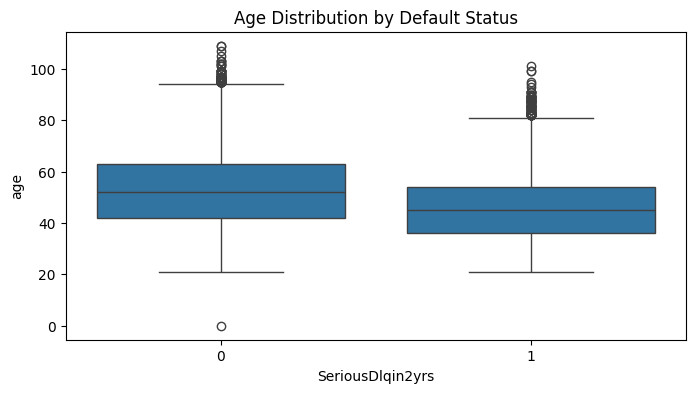

In [17]:
# Compare age by default status
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df,
    x="SeriousDlqin2yrs",
    y="age"
)

plt.title("Age Distribution by Default Status")

plt.show()

### Age Analysis

Most borrowers fall between approximately 30 and 70 years old, with the distribution concentrated around middle-aged individuals. Borrowers who experienced serious financial distress appear slightly younger on average compared to non-default borrowers.

A small number of unusually high age values and one borrower with an age value of `0` appear as potential data quality issues. Overall, age may provide useful predictive signal for default risk and should be explored further during feature analysis.

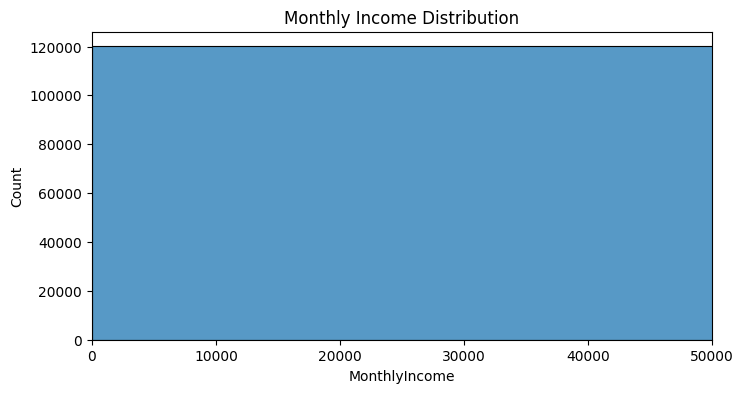

In [18]:
# Visualize monthly income distribution
plt.figure(figsize=(8, 4))

sns.histplot(
    df["MonthlyIncome"],
    bins=50
)

plt.title("Monthly Income Distribution")

plt.xlim(0, 50000)

plt.show()

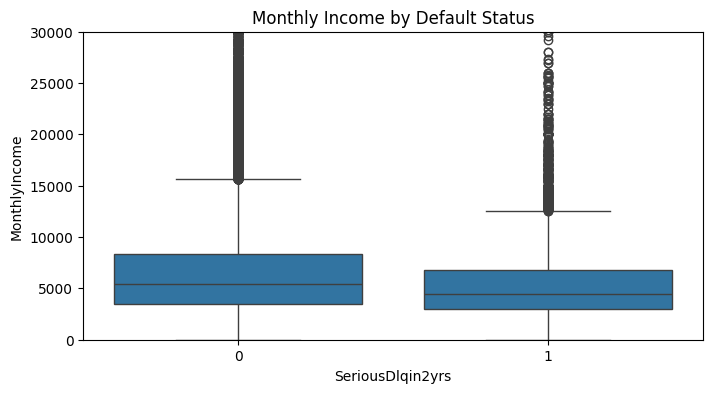

In [19]:
# Compare monthly income by default status
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df,
    x="SeriousDlqin2yrs",
    y="MonthlyIncome"
)

plt.title("Monthly Income by Default Status")

plt.ylim(0, 30000)

plt.show()

### Income Analysis

Monthly income is heavily right-skewed, with a small number of borrowers showing extremely large income values. Most borrowers fall within the lower income ranges, while high-income observations extend far beyond the typical distribution.

Borrowers who experienced serious financial distress appear to have lower median income levels compared to non-default borrowers, although both groups contain substantial outliers.

### Visualization Notes

Axis limits were intentionally applied to improve readability. Without limiting the scale, extreme income outliers compress most observations into a very small visible range, making the distribution difficult to interpret visually.

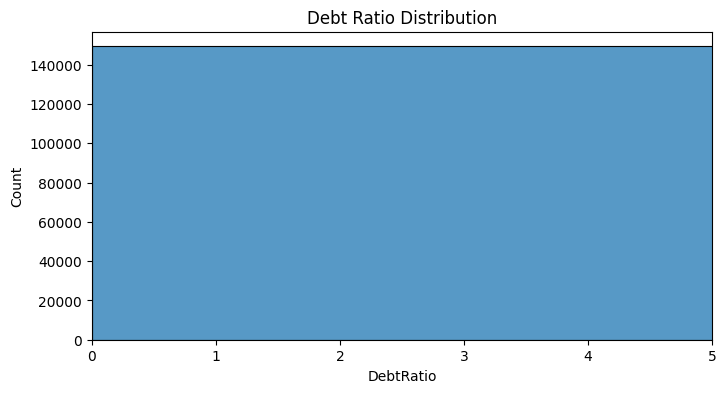

In [20]:
# Visualize debt ratio distribution
plt.figure(figsize=(8, 4))

sns.histplot(
    df["DebtRatio"],
    bins=50
)

plt.title("Debt Ratio Distribution")

plt.xlim(0, 5)

plt.show()

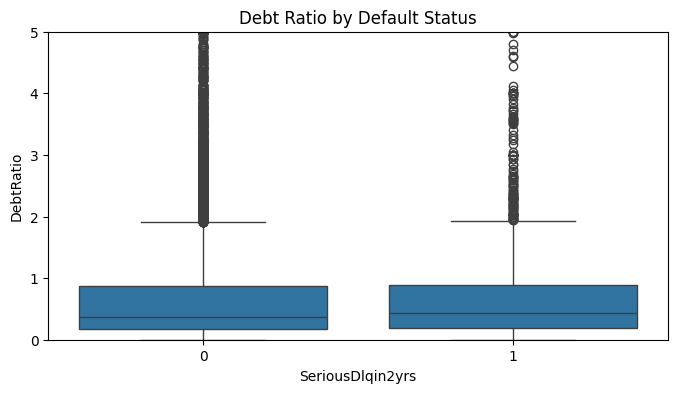

In [21]:
# Compare debt ratio by default status
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df,
    x="SeriousDlqin2yrs",
    y="DebtRatio"
)

plt.title("Debt Ratio by Default Status")

plt.ylim(0, 5)

plt.show()

### Debt Ratio Analysis

Debt ratio values are highly right-skewed, with many extreme observations extending far beyond typical borrowing behavior. Most borrowers appear concentrated at lower debt ratio levels, while a smaller group shows unusually large values.

Borrowers who experienced serious financial distress generally show slightly higher debt ratios compared to non-default borrowers. The default group also appears to contain more extreme high-ratio observations.

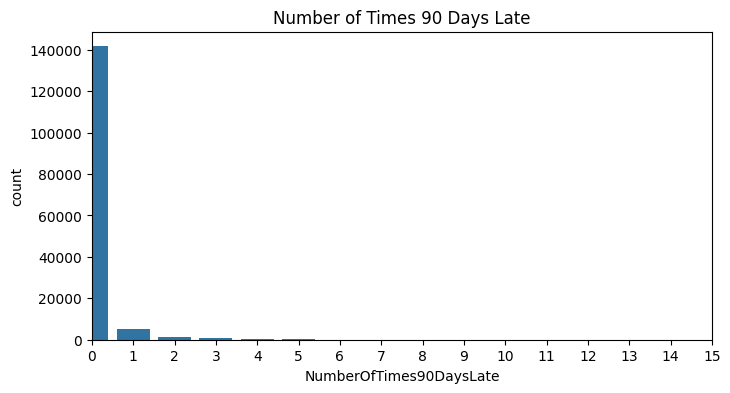

In [22]:
# Visualize 90-days-late distribution
plt.figure(figsize=(8, 4))

sns.countplot(
    data=df,
    x="NumberOfTimes90DaysLate"
)

plt.title("Number of Times 90 Days Late")

plt.xlim(0, 15)

plt.show()

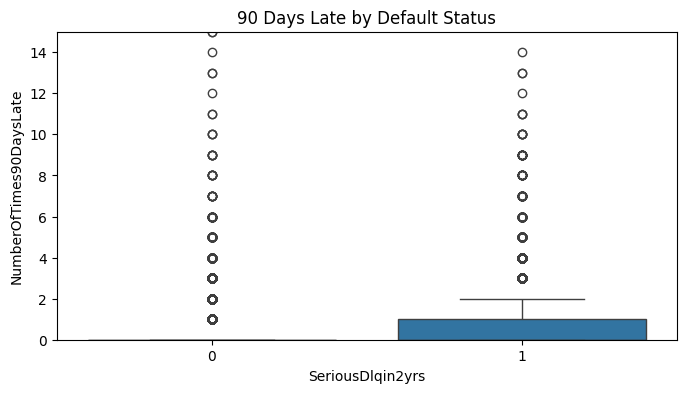

In [23]:
# Compare 90-days-late counts by default status
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df,
    x="SeriousDlqin2yrs",
    y="NumberOfTimes90DaysLate"
)

plt.title("90 Days Late by Default Status")

plt.ylim(0, 15)

plt.show()

### Delinquency Analysis

Most borrowers have no history of being 90 days late, while progressively fewer borrowers appear as delinquency counts increase. The distribution is highly concentrated around zero, which is expected in consumer credit datasets.

Borrowers who experienced serious financial distress generally show higher delinquency counts compared to non-default borrowers. The default group displays a noticeably wider spread of late-payment behavior.

This suggests that severe delinquency history may be an important predictor of future default risk.

In [24]:
# Calculate default rate by 90-days-late count
late_payment_risk = (
    df.groupby("NumberOfTimes90DaysLate")
    ["SeriousDlqin2yrs"]
    .mean()
    .reset_index()
)

late_payment_risk.columns = [
    "LatePayments90Days",
    "DefaultRate"
]

late_payment_risk.head(15)

,LatePayments90Days,DefaultRate
0,0,0.046265
1,1,0.336639
2,2,0.499035
3,3,0.577211
4,4,0.670103
5,5,0.633588
6,6,0.600000
7,7,0.815789
8,8,0.714286
9,9,0.736842


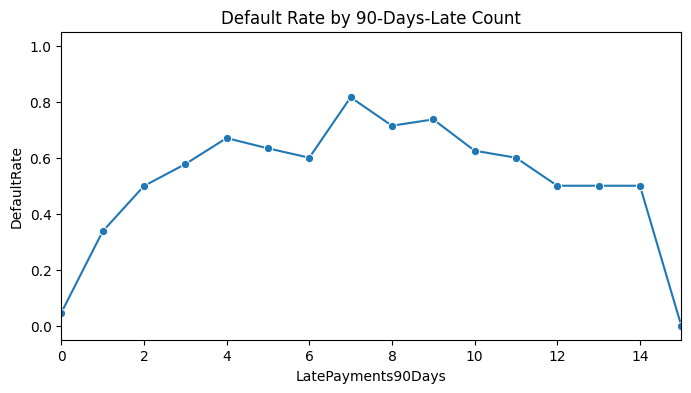

In [25]:
# Visualize default rate by 90-days-late count
plt.figure(figsize=(8, 4))

sns.lineplot(
    data=late_payment_risk,
    x="LatePayments90Days",
    y="DefaultRate",
    marker="o"
)

plt.title("Default Rate by 90-Days-Late Count")

plt.xlim(0, 15)

plt.show()

### Risk Trend Analysis

Default risk increases sharply as the number of 90-days-late payments rises. Borrowers with no severe delinquency history show a relatively low default rate of around 4.6%, while borrowers with multiple severe late payments exhibit substantially higher risk levels.

The relationship is especially strong during the early increases in delinquency count, suggesting that repayment history is likely one of the most important predictors of financial distress in this dataset.

Some fluctuations appear at higher delinquency counts because those groups contain fewer borrowers, making the default rates less stable.

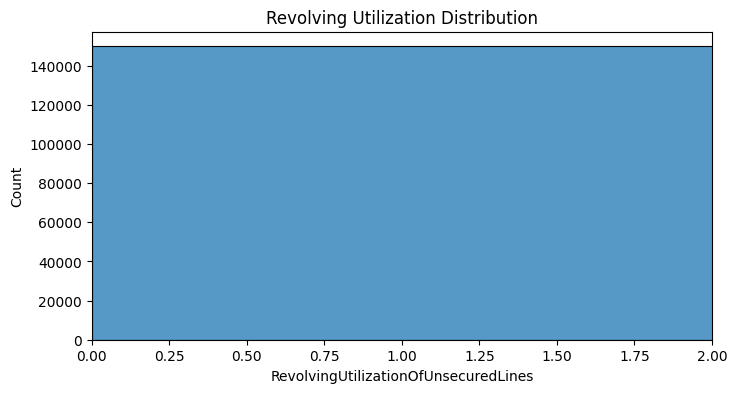

In [26]:
# Visualize revolving utilization distribution
plt.figure(figsize=(8, 4))

sns.histplot(
    df["RevolvingUtilizationOfUnsecuredLines"],
    bins=50
)

plt.title("Revolving Utilization Distribution")

plt.xlim(0, 2)

plt.show()

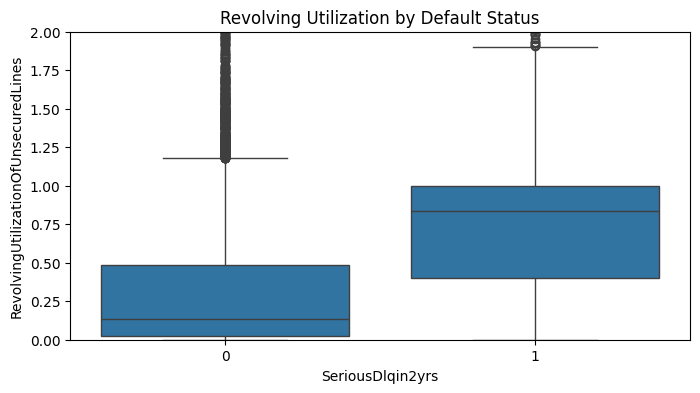

In [27]:
# Compare revolving utilization by default status
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df,
    x="SeriousDlqin2yrs",
    y="RevolvingUtilizationOfUnsecuredLines"
)

plt.title("Revolving Utilization by Default Status")

plt.ylim(0, 2)

plt.show()

### Credit Utilization Analysis

Revolving credit utilization shows a strong relationship with default risk. Borrowers who experienced serious financial distress generally have substantially higher utilization levels compared to non-default borrowers.

The non-default group is concentrated at relatively low utilization levels, while the default group shows a much higher median utilization and wider spread. This suggests that heavy reliance on unsecured revolving credit may be an important indicator of financial stress.

In [28]:
# Calculate feature correlations with target
correlation_with_target = (
    df.corr(numeric_only=True)
    ["SeriousDlqin2yrs"]
    .sort_values(ascending=False)
)

correlation_with_target

SeriousDlqin2yrs                        1.000000
NumberOfTime30-59DaysPastDueNotWorse    0.125587
NumberOfTimes90DaysLate                 0.117175
NumberOfTime60-89DaysPastDueNotWorse    0.102261
NumberOfDependents                      0.046048
RevolvingUtilizationOfUnsecuredLines   -0.001802
NumberRealEstateLoansOrLines           -0.007038
DebtRatio                              -0.007602
MonthlyIncome                          -0.019746
NumberOfOpenCreditLinesAndLoans        -0.029669
age                                    -0.115386
Name: SeriousDlqin2yrs, dtype: float64

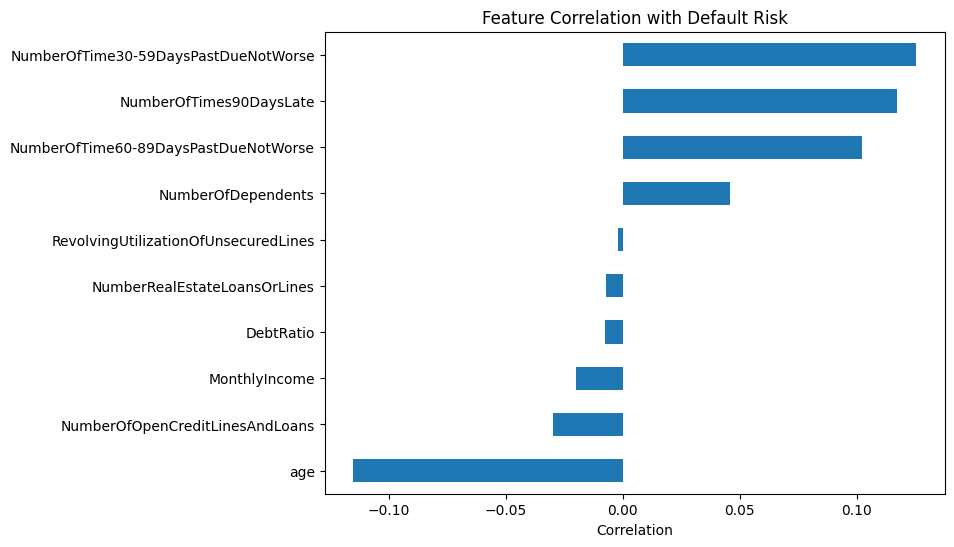

In [29]:
# Visualize correlations with target
plt.figure(figsize=(8, 6))

correlation_with_target.drop(
    "SeriousDlqin2yrs"
).sort_values().plot(
    kind="barh"
)

plt.title("Feature Correlation with Default Risk")

plt.xlabel("Correlation")

plt.show()

### Correlation Analysis

Delinquency-related variables show the strongest positive relationship with default risk. Borrowers with more frequent late-payment history are generally more likely to experience serious financial distress.

`NumberOfTime30-59DaysPastDueNotWorse`, `NumberOfTimes90DaysLate`, and `NumberOfTime60-89DaysPastDueNotWorse` appear to be the most influential risk indicators based on linear correlation strength.

Age shows a moderate negative relationship with default risk, suggesting that younger borrowers may be more likely to default. Monthly income and number of open credit lines also show slight negative relationships with financial distress.

Some variables, such as `DebtRatio` and `RevolvingUtilizationOfUnsecuredLines`, show surprisingly weak linear correlations despite earlier visual patterns. This may indicate the presence of non-linear relationships, extreme outliers, or skewed distributions that are not fully captured by simple correlation analysis.

In [30]:
# Create age groups
df["AgeGroup"] = pd.cut(
    df["age"],
    bins=[20, 30, 40, 50, 60, 70, 110],
    labels=[
        "20-30",
        "31-40",
        "41-50",
        "51-60",
        "61-70",
        "71+"
    ]
)

df["AgeGroup"].value_counts()

AgeGroup
41-50    35037
51-60    34806
61-70    27424
31-40    24339
71+      17636
20-30    10757
Name: count, dtype: int64

In [31]:
# Calculate default rate by age group
age_risk = (
    df.groupby("AgeGroup")
    ["SeriousDlqin2yrs"]
    .mean()
    .reset_index()
)

age_risk.columns = [
    "AgeGroup",
    "DefaultRate"
]

age_risk

,AgeGroup,DefaultRate
0,20-30,0.115646
1,31-40,0.098196
2,41-50,0.082570
3,51-60,0.061742
4,61-70,0.034714
5,71+,0.022567


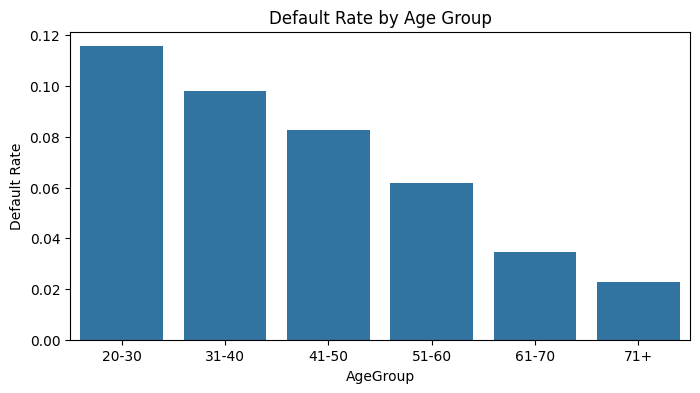

In [32]:
# Visualize default rate by age group
plt.figure(figsize=(8, 4))

sns.barplot(
    data=age_risk,
    x="AgeGroup",
    y="DefaultRate"
)

plt.title("Default Rate by Age Group")

plt.ylabel("Default Rate")

plt.show()

### Age Risk Segmentation

Default risk decreases steadily as borrower age increases. The youngest borrowers between 20 and 30 years old show the highest default rate at approximately 11.6%, while borrowers aged 71 and above show the lowest default risk.

This trend suggests that younger borrowers may face greater financial instability or repayment challenges compared to older borrowers. Older borrowers generally appear to exhibit more stable repayment behavior.

The relationship between age and default risk is consistent with the earlier correlation analysis, where age showed a negative relationship with financial distress risk.

In [33]:
# Create income groups
df["IncomeGroup"] = pd.qcut(
    df["MonthlyIncome"],
    q=5,
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

df["IncomeGroup"].value_counts()

IncomeGroup
Very Low     25084
High         24084
Medium       24057
Very High    24020
Low          23024
Name: count, dtype: int64

In [34]:
# Calculate default rate by income group
income_risk = (
    df.groupby("IncomeGroup")
    ["SeriousDlqin2yrs"]
    .mean()
    .reset_index()
)

income_risk.columns = [
    "IncomeGroup",
    "DefaultRate"
]

income_risk

,IncomeGroup,DefaultRate
0,Very Low,0.090775
1,Low,0.085954
2,Medium,0.070125
3,High,0.055306
4,Very High,0.045046


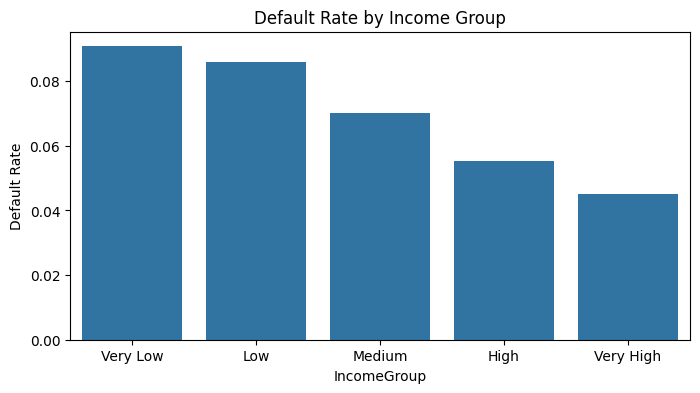

In [35]:
# Visualize default rate by income group
plt.figure(figsize=(8, 4))

sns.barplot(
    data=income_risk,
    x="IncomeGroup",
    y="DefaultRate"
)

plt.title("Default Rate by Income Group")

plt.ylabel("Default Rate")

plt.show()

### Income Risk Segmentation

Default risk declines consistently as borrower income increases. Borrowers in the very low income group show the highest default rates, while borrowers in the very high income group exhibit the lowest risk levels.

This pattern suggests that income level is an important indicator of repayment capacity and financial stability. Higher-income borrowers may have greater ability to absorb financial shocks and manage debt obligations.

The relationship also aligns with earlier findings where defaulted borrowers generally showed lower income levels compared to non-default borrowers.

In [36]:
# Create utilization groups
df["UtilizationGroup"] = pd.cut(
    df["RevolvingUtilizationOfUnsecuredLines"],
    bins=[0, 0.3, 0.6, 0.9, 1.2, 2],
    labels=[
        "Very Low",
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]
)

df["UtilizationGroup"].value_counts()

UtilizationGroup
Very Low     82004
Low          21887
High         19031
Moderate     15162
Very High      667
Name: count, dtype: int64

In [37]:
# Calculate default rate by utilization group
utilization_risk = (
    df.groupby("UtilizationGroup")
    ["SeriousDlqin2yrs"]
    .mean()
    .reset_index()
)

utilization_risk.columns = [
    "UtilizationGroup",
    "DefaultRate"
]

utilization_risk

,UtilizationGroup,DefaultRate
0,Very Low,0.021231
1,Low,0.066798
2,Moderate,0.133030
3,High,0.216541
4,Very High,0.466267


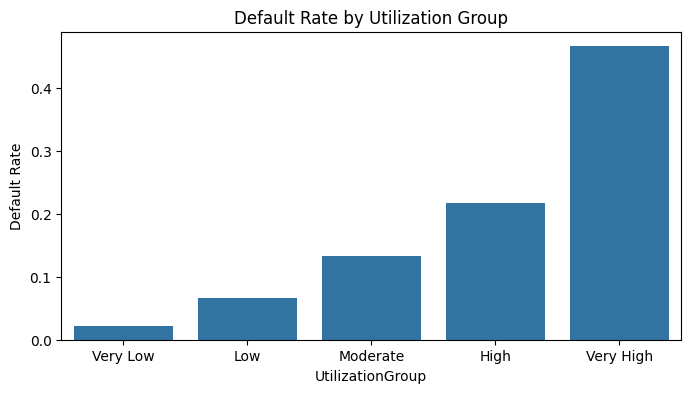

In [38]:
# Visualize default rate by utilization group
plt.figure(figsize=(8, 4))

sns.barplot(
    data=utilization_risk,
    x="UtilizationGroup",
    y="DefaultRate"
)

plt.title("Default Rate by Utilization Group")

plt.ylabel("Default Rate")

plt.show()

### Credit Utilization Risk Segmentation

Default risk increases sharply as revolving credit utilization rises. Borrowers in the very low utilization group show relatively low default rates, while borrowers in the very high utilization group exhibit substantially elevated risk levels.

The increase in default risk appears gradual across utilization bands, suggesting a strong relationship between heavy credit usage and financial distress. Borrowers with utilization levels above 1.2 show particularly high default rates, approaching nearly 47%.

This pattern indicates that revolving credit utilization may be one of the most important predictors of borrower risk in the dataset and could play a major role in the future credit scoring system.

## 📌 Key EDA Findings

### Main Findings

- The dataset contains significant class imbalance, with most borrowers belonging to the non-default class.
- `MonthlyIncome` and `NumberOfDependents` contain missing values that will require preprocessing.
- Several variables contain suspicious or unrealistic values, including extreme utilization ratios, unusually large debt ratios, and repeated delinquency values of `98`.
- Delinquency-related variables show the strongest positive relationship with default risk.
- Younger borrowers generally exhibit higher default rates compared to older borrowers.
- Lower-income borrowers show substantially higher financial distress risk than higher-income borrowers.
- Revolving credit utilization demonstrates one of the clearest relationships with default probability, with risk increasing sharply at higher utilization levels.

### Business Interpretation

The exploratory analysis suggests that borrower repayment behavior, credit utilization, and financial capacity are important drivers of default risk. Several strong risk patterns identified during EDA may later contribute significantly to model performance and credit scoring decisions.

The findings also highlight the importance of careful preprocessing and outlier handling before model development.

## 🛠️ Data Preprocessing

In [39]:
# Create preprocessing copy
df_prep = df.copy()

df_prep.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,AgeGroup,IncomeGroup,UtilizationGroup
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,41-50,Very High,Moderate
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,31-40,Very Low,High
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,31-40,Low,Moderate
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,20-30,Low,Very Low
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0,41-50,Very High,High


In [40]:
# Check preprocessing dataset shape
print(f"Rows: {df_prep.shape[0]}")
print(f"Columns: {df_prep.shape[1]}")

Rows: 150000
Columns: 14


In [41]:
# View preprocessing columns
df_prep.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents', 'AgeGroup', 'IncomeGroup', 'UtilizationGroup'],
      dtype='object')

In [42]:
# Remove temporary EDA columns
df_prep = df_prep.drop(
    columns=[
        "AgeGroup",
        "IncomeGroup",
        "UtilizationGroup"
    ]
)

df_prep.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [43]:
# Check updated preprocessing columns
df_prep.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

### Preprocessing Notes

The temporary segmentation variables created during exploratory analysis were removed before modeling preparation. These columns were useful for business interpretation and visualization but are derived directly from existing numerical features.

Removing them helps keep the preprocessing pipeline cleaner and avoids introducing redundant information into the modeling stage.

In [44]:
# Check frequency of delinquency values
delinquency_columns = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate"
]

for column in delinquency_columns:
    
    print(f"\n{column}")
    print(df_prep[column].value_counts().head(15))


NumberOfTime30-59DaysPastDueNotWorse
NumberOfTime30-59DaysPastDueNotWorse
0     126018
1      16033
2       4598
3       1754
4        747
5        342
98       264
6        140
7         54
8         25
9         12
96         5
10         4
12         2
13         1
Name: count, dtype: int64

NumberOfTime60-89DaysPastDueNotWorse
NumberOfTime60-89DaysPastDueNotWorse
0     142396
1       5731
2       1118
3        318
98       264
4        105
5         34
6         16
7          9
96         5
8          2
11         1
9          1
Name: count, dtype: int64

NumberOfTimes90DaysLate
NumberOfTimes90DaysLate
0     141662
1       5243
2       1555
3        667
4        291
98       264
5        131
6         80
7         38
8         21
9         19
10         8
96         5
11         5
13         4
Name: count, dtype: int64


In [45]:
# Check suspicious delinquency records
df_prep[
    (
        df_prep["NumberOfTime30-59DaysPastDueNotWorse"] >= 90
    ) |
    (
        df_prep["NumberOfTime60-89DaysPastDueNotWorse"] >= 90
    ) |
    (
        df_prep["NumberOfTimes90DaysLate"] >= 90
    )
].head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1733,1,1.0,27,98,0.0,2700.0,0,98,0,98,0.0
2286,0,1.0,22,98,0.0,NaN,0,98,0,98,0.0
3884,0,1.0,38,98,12.0,NaN,0,98,0,98,0.0
4417,0,1.0,21,98,0.0,0.0,0,98,0,98,0.0
4705,0,1.0,21,98,0.0,2000.0,0,98,0,98,0.0


In [46]:
# Replace suspicious delinquency values with NaN
delinquency_columns = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate"
]

for column in delinquency_columns:
    
    df_prep[column] = df_prep[column].replace(
        [96, 98],
        np.nan
    )

In [47]:
# Check delinquency values after replacement
for column in delinquency_columns:
    
    print(f"\n{column}")
    print(df_prep[column].value_counts().head(10))


NumberOfTime30-59DaysPastDueNotWorse
NumberOfTime30-59DaysPastDueNotWorse
0.0    126018
1.0     16033
2.0      4598
3.0      1754
4.0       747
5.0       342
6.0       140
7.0        54
8.0        25
9.0        12
Name: count, dtype: int64

NumberOfTime60-89DaysPastDueNotWorse
NumberOfTime60-89DaysPastDueNotWorse
0.0     142396
1.0       5731
2.0       1118
3.0        318
4.0        105
5.0         34
6.0         16
7.0          9
8.0          2
11.0         1
Name: count, dtype: int64

NumberOfTimes90DaysLate
NumberOfTimes90DaysLate
0.0    141662
1.0      5243
2.0      1555
3.0       667
4.0       291
5.0       131
6.0        80
7.0        38
8.0        21
9.0        19
Name: count, dtype: int64


In [48]:
# Check updated missing values
missing_values = df_prep.isnull().sum()

missing_summary = pd.DataFrame({
    "MissingValues": missing_values,
    "Percentage": (
        missing_values / len(df_prep) * 100
    ).round(2)
})

missing_summary.sort_values(
    by="MissingValues",
    ascending=False
)

,MissingValues,Percentage
MonthlyIncome,29731,19.82
NumberOfDependents,3924,2.62
NumberOfTimes90DaysLate,269,0.18
NumberOfTime60-89DaysPastDueNotWorse,269,0.18
NumberOfTime30-59DaysPastDueNotWorse,269,0.18
SeriousDlqin2yrs,0,0.00
RevolvingUtilizationOfUnsecuredLines,0,0.00
age,0,0.00
DebtRatio,0,0.00
NumberOfOpenCreditLinesAndLoans,0,0.00


### Data Cleaning Decisions

The repeated delinquency values `96` and `98` were treated as invalid observations and converted to missing values. These values appeared consistently across multiple delinquency variables and did not represent realistic repayment behavior.

Instead of removing the affected borrower records, the suspicious values were replaced with `NaN` to preserve the remaining borrower information for later preprocessing and modeling.

After replacement, the delinquency variables now contain a small number of missing values in addition to the existing missing values in `MonthlyIncome` and `NumberOfDependents`.

In [49]:
# Create missing income indicator
df_prep["MissingIncome"] = (
    df_prep["MonthlyIncome"]
    .isnull()
    .astype(int)
)

df_prep["MissingIncome"].value_counts()

MissingIncome
0    120269
1     29731
Name: count, dtype: int64

In [50]:
# Compare default rate by missing income status
missing_income_risk = (
    df_prep.groupby("MissingIncome")
    ["SeriousDlqin2yrs"]
    .mean()
    .reset_index()
)

missing_income_risk.columns = [
    "MissingIncome",
    "DefaultRate"
]

missing_income_risk

,MissingIncome,DefaultRate
0,0,0.069486
1,1,0.056137


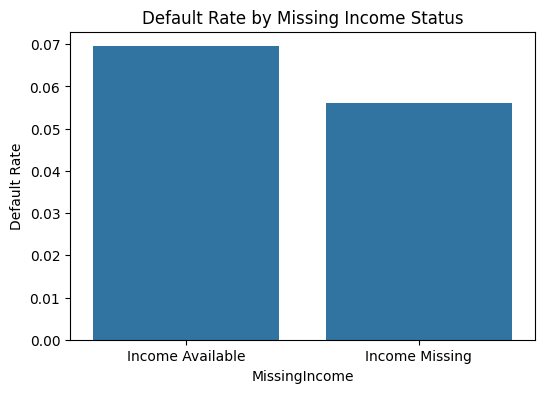

In [51]:
# Visualize default rate by missing income status
plt.figure(figsize=(6, 4))

sns.barplot(
    data=missing_income_risk,
    x="MissingIncome",
    y="DefaultRate"
)

plt.title("Default Rate by Missing Income Status")

plt.xticks(
    [0, 1],
    ["Income Available", "Income Missing"]
)

plt.ylabel("Default Rate")

plt.show()

### Missing Income Analysis

Borrowers with missing income values do not appear to exhibit higher default risk compared to borrowers with available income information. In fact, the group with missing income shows a slightly lower default rate in this dataset.

This suggests that missing income may not necessarily represent financially riskier borrowers. However, the missingness pattern may still contain useful information, so the `MissingIncome` indicator feature will be retained for modeling.

Creating explicit missing-value indicators can help models capture patterns related to incomplete financial records without discarding borrower observations.

In [52]:
# Fill missing MonthlyIncome values
monthly_income_median = (
    df_prep["MonthlyIncome"]
    .median()
)

df_prep["MonthlyIncome"] = (
    df_prep["MonthlyIncome"]
    .fillna(monthly_income_median)
)

In [53]:
# Fill missing NumberOfDependents values
dependents_median = (
    df_prep["NumberOfDependents"]
    .median()
)

df_prep["NumberOfDependents"] = (
    df_prep["NumberOfDependents"]
    .fillna(dependents_median)
)

In [54]:
# Fill missing delinquency values
for column in delinquency_columns:
    
    median_value = (
        df_prep[column]
        .median()
    )
    
    df_prep[column] = (
        df_prep[column]
        .fillna(median_value)
    )

In [55]:
# Check remaining missing values
df_prep.isnull().sum()

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
MissingIncome                           0
dtype: int64

### Missing Value Handling

Missing values were handled using median imputation rather than mean imputation because several financial variables contain skewed distributions and extreme outliers. Median values provide a more robust estimate that is less sensitive to unusually large observations.

A separate `MissingIncome` indicator feature was retained to preserve potential information related to missing financial records.

After preprocessing, the dataset no longer contains missing values and is ready for model preparation.

In [56]:
# Display high percentile values
outlier_columns = [
    "RevolvingUtilizationOfUnsecuredLines",
    "DebtRatio",
    "MonthlyIncome"
]

for column in outlier_columns:
    
    print(f"\n{column}")
    
    print(
        df_prep[column].quantile(
            [0.50, 0.75, 0.90, 0.95, 0.99]
        )
    )


RevolvingUtilizationOfUnsecuredLines
0.50    0.154181
0.75    0.559046
0.90    0.981278
0.95    1.000000
0.99    1.092956
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

DebtRatio
0.50       0.366508
0.75       0.868254
0.90    1267.000000
0.95    2449.000000
0.99    4979.040000
Name: DebtRatio, dtype: float64

MonthlyIncome
0.50     5400.0
0.75     7400.0
0.90    10750.0
0.95    13500.0
0.99    23000.0
Name: MonthlyIncome, dtype: float64


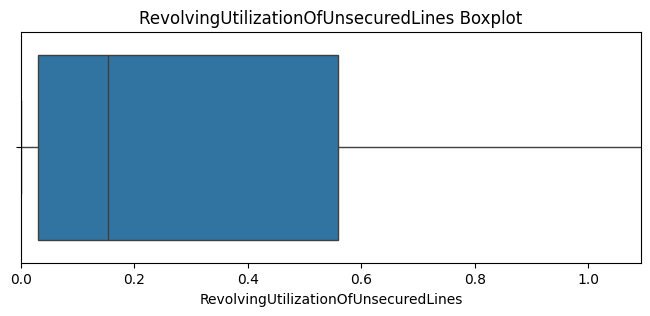

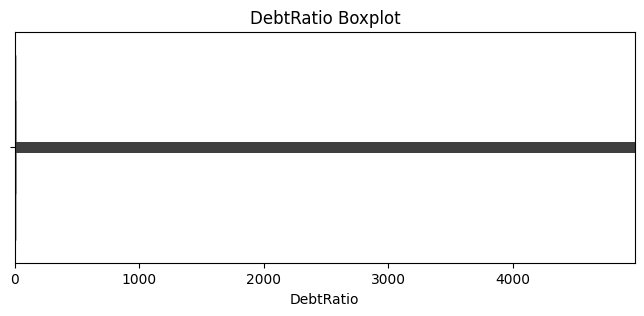

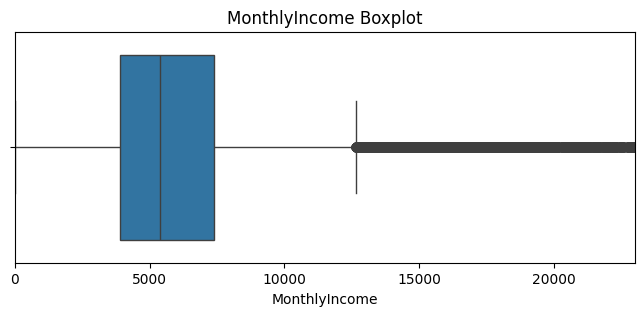

In [57]:
# Visualize financial outliers
for column in outlier_columns:
    
    plt.figure(figsize=(8, 3))
    
    sns.boxplot(
        x=df_prep[column]
    )
    
    plt.title(f"{column} Boxplot")
    
    plt.xlim(
        0,
        df_prep[column].quantile(0.99)
    )
    
    plt.show()

### Outlier Analysis

The financial variables show very different outlier behaviors across the dataset.

`RevolvingUtilizationOfUnsecuredLines` appears relatively concentrated for most borrowers, although a small number of observations slightly exceed normal utilization ranges. The majority of borrowers remain below a utilization value of 1.

`DebtRatio` contains extremely large values far beyond typical borrowing behavior. The sharp jump between the 75th percentile and higher percentiles suggests the presence of substantial outliers or potentially unrealistic financial records.

`MonthlyIncome` is right-skewed with high-income outliers, but the distribution appears more manageable and less extreme compared to `DebtRatio`.

### Modeling Considerations

Extreme financial values may distort model behavior, especially for linear models such as logistic regression. However, some extreme observations may also represent genuinely high-risk borrowers.

Instead of removing large numbers of rows, selective outlier treatment or capping strategies may provide a better balance between preserving risk information and stabilizing model performance.

In [58]:
# Cap revolving utilization outliers
utilization_cap = (
    df_prep[
        "RevolvingUtilizationOfUnsecuredLines"
    ].quantile(0.99)
)

df_prep[
    "RevolvingUtilizationOfUnsecuredLines"
] = np.where(
    df_prep[
        "RevolvingUtilizationOfUnsecuredLines"
    ] > utilization_cap,
    utilization_cap,
    df_prep[
        "RevolvingUtilizationOfUnsecuredLines"
    ]
)

In [59]:
# Cap debt ratio outliers
debt_ratio_cap = (
    df_prep["DebtRatio"]
    .quantile(0.99)
)

df_prep["DebtRatio"] = np.where(
    df_prep["DebtRatio"] > debt_ratio_cap,
    debt_ratio_cap,
    df_prep["DebtRatio"]
)

In [60]:
# Check capped percentile values
df_prep[
    [
        "RevolvingUtilizationOfUnsecuredLines",
        "DebtRatio"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
RevolvingUtilizationOfUnsecuredLines,150000.0,0.320496,0.352152,0.0,0.029867,0.154181,0.559046,1.092956
DebtRatio,150000.0,316.548869,906.962222,0.0,0.175074,0.366508,0.868254,4979.040000


### Outlier Treatment

Extreme values in `RevolvingUtilizationOfUnsecuredLines` and `DebtRatio` were capped at the 99th percentile to reduce the influence of unrealistic or highly distorted observations.

This approach preserves the majority of borrower records while limiting the impact of extreme tails that could destabilize model training. The strategy is less aggressive than removing outlier rows entirely and is more appropriate for financial risk datasets where some high-risk behavior may still be legitimate.

`MonthlyIncome` was kept unchanged because high income values may still represent legitimate borrower profiles rather than data quality issues. Compared to `DebtRatio`, the income distribution appeared more reasonable and less severely distorted.

After capping, the distributions remain right-skewed but are substantially more controlled and suitable for modeling.

In [61]:
# Define features and target
X = df_prep.drop(
    columns="SeriousDlqin2yrs"
)

y = df_prep["SeriousDlqin2yrs"]

print(X.shape)
print(y.shape)

(150000, 11)
(150000,)


In [62]:
# Check target distribution
y.value_counts(normalize=True)

SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64

### Modeling Preparation

The dataset has been separated into feature variables (`X`) and the target variable (`y`) for model development.

The target distribution remains highly imbalanced, with approximately 93.3% of borrowers belonging to the non-default class and only 6.7% belonging to the default class.

This imbalance is important because standard accuracy metrics may become misleading during model evaluation. Later modeling stages will therefore focus more heavily on recall, precision, ROC-AUC, probability calibration, and threshold optimization.

## 📌 Preprocessing Summary

### Main Preprocessing Steps

- Removed temporary EDA segmentation variables before modeling.
- Investigated and handled suspicious delinquency values (`96` and `98`) by converting them to missing values.
- Created a missing income indicator feature to preserve missingness information.
- Applied median imputation to skewed financial variables with missing values.
- Capped extreme outliers in utilization and debt ratio variables using the 99th percentile.
- Prepared separate feature and target datasets for modeling.

## 🤖 Baseline Modeling

In [63]:
# Import modeling tools
from sklearn.model_selection import train_test_split

In [64]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (120000, 11)
X_test shape: (30000, 11)
y_train shape: (120000,)
y_test shape: (30000,)


In [65]:
# Check target balance after split
split_balance = pd.DataFrame({
    "Training Set": y_train.value_counts(normalize=True),
    "Testing Set": y_test.value_counts(normalize=True)
})

split_balance

,Training Set,Testing Set
SeriousDlqin2yrs,,
0,0.933158,0.933167
1,0.066842,0.066833


### Train-Test Split

The dataset was split into training and testing sets using stratified sampling to preserve the original target distribution across both subsets.

The class imbalance remained highly consistent after the split, with approximately 93.3% non-default borrowers and 6.7% default borrowers in both the training and testing sets.

Using stratification is especially important for imbalanced credit risk datasets because it helps ensure that model evaluation reflects realistic borrower risk proportions.

In [66]:
# Import scaler
from sklearn.preprocessing import StandardScaler

In [67]:
# Scale training and testing features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [68]:
# Check scaled feature shapes
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(120000, 11)
(30000, 11)


### Feature Scaling

Feature scaling was applied using `StandardScaler` to standardize the numerical variables before training scale-sensitive models such as logistic regression.

The financial variables in the dataset operate on very different ranges. For example, age, income, debt ratio, and utilization values differ substantially in scale, which can negatively affect optimization and coefficient stability in linear models.

Scaling was performed using only the training data to avoid data leakage into the testing set.

In [69]:
# Import logistic regression
from sklearn.linear_model import LogisticRegression

In [70]:
# Train logistic regression model
log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_reg.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [71]:
# Generate predictions
y_pred = log_reg.predict(X_test_scaled)

y_pred_proba = log_reg.predict_proba(
    X_test_scaled
)[:, 1]

In [72]:
# View predicted probabilities
y_pred_proba[:10]

array([0.0147857 , 0.02908484, 0.01332384, 0.01831264, 0.01922226,
       0.01072834, 0.01251253, 0.09708725, 0.02449239, 0.02978171])

In [73]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [74]:
# Create model results list
model_results = []

In [75]:
# Create evaluation function
def evaluate_model(model_name, model, X_valid, y_valid):

    y_pred = model.predict(X_valid)

    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(
            X_valid
        )[:, 1]
    else:
        y_pred_proba = y_pred

    accuracy = accuracy_score(
        y_valid,
        y_pred
    )

    precision = precision_score(
        y_valid,
        y_pred
    )

    recall = recall_score(
        y_valid,
        y_pred
    )

    f1 = f1_score(
        y_valid,
        y_pred
    )

    roc_auc = roc_auc_score(
        y_valid,
        y_pred_proba
    )

    print(f"{model_name} Performance")
    print("-" * 40)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_valid,
            y_pred
        )
    )

    results = {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": roc_auc
    }

    model_results.append(results)

    return results

In [76]:
# Evaluate logistic regression
log_reg_results = evaluate_model(
    model_name="Logistic Regression",
    model=log_reg,
    X_valid=X_test_scaled,
    y_valid=y_test
)

Logistic Regression Performance
----------------------------------------
Accuracy : 0.9374
Precision: 0.6171
Recall   : 0.1656
F1-Score : 0.2611
ROC-AUC  : 0.8543

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27995
           1       0.62      0.17      0.26      2005

    accuracy                           0.94     30000
   macro avg       0.78      0.58      0.61     30000
weighted avg       0.92      0.94      0.92     30000



### Logistic Regression Performance

The baseline logistic regression model achieved a strong ROC-AUC score of approximately 0.85, indicating good overall ability to separate high-risk and low-risk borrowers.

However, the model shows relatively low recall for the default class. Only around 16.6% of actual default borrowers were correctly identified, despite the model achieving high overall accuracy.

This highlights a common issue in imbalanced credit risk datasets: high accuracy can be misleading because the model correctly predicts the majority non-default class most of the time.

From a business perspective, low recall may be problematic because many risky borrowers would still be approved and could later default. This tradeoff between identifying risky borrowers and minimizing false alarms will become important during threshold optimization later in the project.

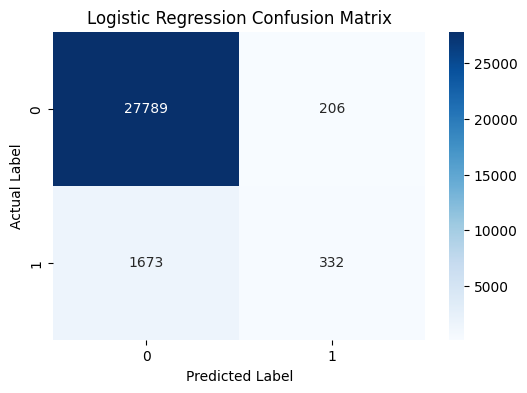

In [77]:
# Visualize confusion matrix
plt.figure(figsize=(6, 4))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

### Confusion Matrix Interpretation

The confusion matrix shows that the model correctly identified most non-default borrowers, with only a small number of false positive predictions.

However, the model failed to identify a large portion of actual default borrowers. Out of 2,005 true default cases, only 332 were correctly classified, while 1,673 risky borrowers were incorrectly predicted as low risk.

From a lending perspective, these false negatives are especially important because they represent borrowers who may be approved despite having elevated default risk.

This result suggests that the default classification threshold of 0.5 may be too conservative for credit risk prediction. Lowering the threshold later may help improve recall and identify more high-risk borrowers, although this will likely increase false positives.

In [78]:
# Import random forest
from sklearn.ensemble import RandomForestClassifier

In [79]:
# Train random forest model
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(
    X_train,
    y_train
)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [80]:
# Evaluate random forest model
rf_results = evaluate_model(
    model_name="Random Forest",
    model=random_forest,
    X_valid=X_test,
    y_valid=y_test
)

Random Forest Performance
----------------------------------------
Accuracy : 0.9353
Precision: 0.5494
Recall   : 0.1776
F1-Score : 0.2684
ROC-AUC  : 0.8390

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27995
           1       0.55      0.18      0.27      2005

    accuracy                           0.94     30000
   macro avg       0.75      0.58      0.62     30000
weighted avg       0.92      0.94      0.92     30000



### Random Forest Performance

The Random Forest model achieved performance comparable to logistic regression, but it did not produce a substantial improvement in recall or ROC-AUC score.

While the model captured some non-linear relationships within the dataset, its ability to identify default borrowers remained relatively limited under the default classification threshold.

Compared to logistic regression:

- Recall improved slightly from approximately 16.6% to 17.8%.
- Precision decreased from approximately 61.7% to 54.9%.
- ROC-AUC declined slightly from 0.854 to 0.839.

These results suggest that increasing model complexity alone does not automatically lead to significantly better credit risk detection. Threshold tuning and probability calibration may ultimately have a larger impact on lending decision quality than simply switching models.

In [81]:
# Import XGBoost
from xgboost import XGBClassifier

In [82]:
# Train XGBoost model
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [83]:
# Evaluate XGBoost model
xgb_results = evaluate_model(
    model_name="XGBoost",
    model=xgb_model,
    X_valid=X_test,
    y_valid=y_test
)

XGBoost Performance
----------------------------------------
Accuracy : 0.9375
Precision: 0.6062
Recall   : 0.1865
F1-Score : 0.2853
ROC-AUC  : 0.8684

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27995
           1       0.61      0.19      0.29      2005

    accuracy                           0.94     30000
   macro avg       0.78      0.59      0.63     30000
weighted avg       0.92      0.94      0.92     30000



### XGBoost Performance

XGBoost achieved the strongest overall performance among the models tested so far, producing the highest ROC-AUC score and the best balance between precision and recall.

Compared to logistic regression and random forest, the model identified a larger proportion of default borrowers while maintaining relatively strong precision. This suggests that XGBoost is better able to capture complex non-linear relationships within borrower financial behavior.

Although recall remains relatively modest under the default classification threshold, the improvement in ranking performance indicates that the model may be especially useful for probability-based credit scoring and threshold optimization later in the project.

In [84]:
# Import LightGBM
from lightgbm import LGBMClassifier

In [85]:
# Train LightGBM model
lgbm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    verbose=-1
)

lgbm_model.fit(
    X_train,
    y_train
)

LGBMClassifier(learning_rate=0.05, max_depth=5, n_estimators=200,
               random_state=42, verbose=-1)

In [86]:
# Evaluate LightGBM model
lgbm_results = evaluate_model(
    model_name="LightGBM",
    model=lgbm_model,
    X_valid=X_test,
    y_valid=y_test
)

LightGBM Performance
----------------------------------------
Accuracy : 0.9365
Precision: 0.5824
Recall   : 0.1781
F1-Score : 0.2727
ROC-AUC  : 0.8680

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27995
           1       0.58      0.18      0.27      2005

    accuracy                           0.94     30000
   macro avg       0.76      0.58      0.62     30000
weighted avg       0.92      0.94      0.92     30000



### LightGBM Performance

LightGBM achieved performance comparable to XGBoost and outperformed the Random Forest baseline across most evaluation metrics.

The model demonstrated strong ranking capability with a high ROC-AUC score, suggesting that it can effectively distinguish between lower-risk and higher-risk borrowers. However, recall for the default class remained relatively limited under the default classification threshold.

Compared to XGBoost, LightGBM produced slightly lower recall and ROC-AUC scores in this experiment. Nevertheless, both boosting models significantly improved overall predictive performance compared to the earlier baseline models.

In [87]:
# Compare model performance
results_df = pd.DataFrame(model_results)

results_df.sort_values(
    by="ROC_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
2,XGBoost,0.937533,0.606159,0.186534,0.285278,0.868393
3,LightGBM,0.936533,0.582382,0.178055,0.272727,0.867980
0,Logistic Regression,0.937367,0.617100,0.165586,0.261109,0.854276
1,Random Forest,0.935300,0.549383,0.177556,0.268375,0.838991


## 📌 Baseline Modeling Summary

### Model Comparison

| Model | Key Observation |
|---|---|
| XGBoost | Best overall ROC-AUC and strongest balance between precision and recall |
| LightGBM | Performance close to XGBoost with strong ranking capability |
| Logistic Regression | Highly interpretable and competitive despite lower recall |
| Random Forest | Improved non-linear modeling but weaker overall ranking performance |

The boosting models achieved the strongest overall performance, with XGBoost producing the highest ROC-AUC score at approximately 0.868. This suggests that boosting methods are better able to capture complex borrower risk patterns within the dataset.

Logistic Regression remained surprisingly competitive despite its simplicity and interpretability. This is valuable in financial risk modeling because interpretable models are often preferred in regulated lending environments.

### Business Interpretation

Although all models achieved high accuracy, recall for the default class remained relatively low under the default classification threshold of 0.5. This means that many risky borrowers would still be classified as low risk and could potentially receive loan approval.

From a lending perspective, the probability outputs of the models may be more valuable than the default binary predictions themselves. Improving decision quality will likely depend more on:

- threshold optimization
- probability calibration
- risk segmentation
- approval strategy design

rather than simply increasing model complexity.

Based on the baseline experiments, XGBoost appears to be the strongest candidate for the credit scoring and loan decision system moving forward.

## 💳 Credit Scoring & Loan Decision Logic

In [88]:
# Generate XGBoost probabilities
xgb_proba = xgb_model.predict_proba(
    X_test
)[:, 1]

xgb_proba[:10]

array([0.00799959, 0.02622106, 0.00514819, 0.01289635, 0.01155504,
       0.00380584, 0.00695623, 0.30474967, 0.01738562, 0.03662467],
      dtype=float32)

In [89]:
# Create probability results dataframe
credit_results = X_test.copy()

credit_results["ActualDefault"] = y_test.values

credit_results["DefaultProbability"] = xgb_proba

credit_results.head()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MissingIncome,ActualDefault,DefaultProbability
10682,0.019252,66,0.0,0.433926,5175.0,13,0.0,1,0.0,0.0,0,0,0.008000
40173,0.454221,78,0.0,0.873533,2300.0,7,0.0,1,0.0,2.0,0,0,0.026221
4719,0.077572,59,0.0,0.172882,10833.0,5,0.0,1,0.0,0.0,0,0,0.005148
81730,0.107864,59,0.0,0.453692,9900.0,10,0.0,2,0.0,0.0,0,0,0.012896
113639,0.101095,67,0.0,0.407831,5950.0,14,0.0,2,0.0,0.0,0,0,0.011555


### Probability-Based Risk Prediction

The XGBoost model generates predicted default probabilities rather than only binary classifications. These probabilities estimate the likelihood that a borrower may experience serious financial distress within two years.

Probability-based outputs are especially important in credit risk modeling because lending decisions are rarely purely binary. Instead of treating all borrowers equally, financial institutions often use probability estimates to:

- assign credit risk scores
- segment borrowers into risk categories
- define approval and rejection thresholds
- support manual review processes
- estimate potential lending exposure

This approach provides more flexibility and business value compared to relying only on default class predictions.

In [90]:
# Create probability-based risk categories
credit_results["RiskCategory"] = pd.cut(
    credit_results["DefaultProbability"],
    bins=[0, 0.05, 0.15, 1],
    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

credit_results[
    [
        "DefaultProbability",
        "RiskCategory"
    ]
].head()

,DefaultProbability,RiskCategory
10682,0.008000,Low Risk
40173,0.026221,Low Risk
4719,0.005148,Low Risk
81730,0.012896,Low Risk
113639,0.011555,Low Risk


In [91]:
# Check risk category distribution
credit_results[
    "RiskCategory"
].value_counts()

RiskCategory
Low Risk       20813
Medium Risk     5750
High Risk       3437
Name: count, dtype: int64

In [92]:
# Calculate actual default rate by risk category
risk_summary = (
    credit_results.groupby("RiskCategory")
    ["ActualDefault"]
    .mean()
    .reset_index()
)

risk_summary.columns = [
    "RiskCategory",
    "ActualDefaultRate"
]

risk_summary

,RiskCategory,ActualDefaultRate
0,Low Risk,0.015567
1,Medium Risk,0.086609
2,High Risk,0.344196


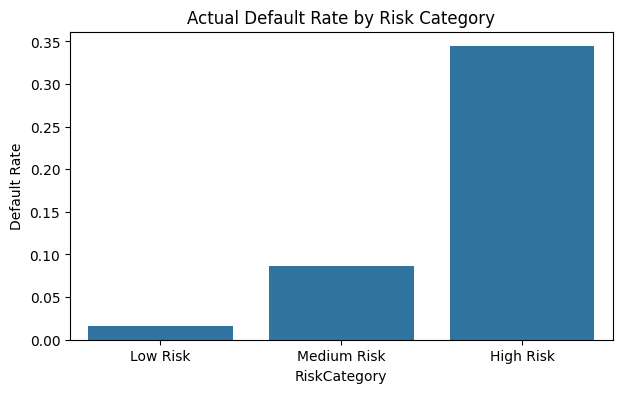

In [93]:
# Visualize default rate by risk category
plt.figure(figsize=(7, 4))

sns.barplot(
    data=risk_summary,
    x="RiskCategory",
    y="ActualDefaultRate"
)

plt.title("Actual Default Rate by Risk Category")

plt.ylabel("Default Rate")

plt.show()

### Risk Segmentation Analysis

The probability-based risk segmentation produced clear separation between borrower risk groups.

Borrowers classified as:

- `Low Risk` showed a default rate of approximately 1.6%
- `Medium Risk` showed a default rate of approximately 8.7%
- `High Risk` showed a default rate above 34%

This demonstrates that the model probabilities successfully capture meaningful differences in borrower financial risk.

The strong separation between categories suggests that the model may be useful for supporting lending decisions, borrower monitoring, and credit portfolio segmentation.

### Business Interpretation

Risk segmentation allows financial institutions to move beyond simple approve/reject decisions and apply more flexible lending strategies.

For example:

- low-risk borrowers may qualify for streamlined approvals
- medium-risk borrowers may require additional review
- high-risk borrowers may trigger stricter lending controls or rejection policies

This type of probability-driven segmentation is commonly used in real-world credit risk management systems.

In [94]:
# Create loan decision logic
conditions = [
    (
        credit_results["DefaultProbability"] < 0.05
    ),

    (
        (
            credit_results["DefaultProbability"] >= 0.05
        ) &
        (
            credit_results["DefaultProbability"] < 0.15
        )
    ),

    (
        credit_results["DefaultProbability"] >= 0.15
    )
]

decisions = [
    "Approve",
    "Manual Review",
    "Reject"
]

credit_results["LoanDecision"] = np.select(
    conditions,
    decisions,
    default="Manual Review"
)

credit_results[
    [
        "DefaultProbability",
        "RiskCategory",
        "LoanDecision"
    ]
].head()

,DefaultProbability,RiskCategory,LoanDecision
10682,0.008000,Low Risk,Approve
40173,0.026221,Low Risk,Approve
4719,0.005148,Low Risk,Approve
81730,0.012896,Low Risk,Approve
113639,0.011555,Low Risk,Approve


In [95]:
# Check loan decision distribution
credit_results[
    "LoanDecision"
].value_counts()

LoanDecision
Approve          20813
Manual Review     5750
Reject            3437
Name: count, dtype: int64

In [96]:
# Calculate default rate by loan decision
decision_summary = (
    credit_results.groupby("LoanDecision")
    ["ActualDefault"]
    .mean()
    .reset_index()
)

decision_summary.columns = [
    "LoanDecision",
    "ActualDefaultRate"
]

decision_summary

,LoanDecision,ActualDefaultRate
0,Approve,0.015567
1,Manual Review,0.086609
2,Reject,0.344196


### Loan Decision Logic

Predicted default probabilities were converted into simplified lending decisions using predefined risk thresholds.

The decision framework was structured as:

- `Approve` → default probability below 5%
- `Manual Review` → default probability between 5% and 15%
- `Reject` → default probability above 15%

The resulting borrower groups showed strong separation in actual default behavior.

Approved borrowers exhibited very low observed default rates, while rejected borrowers showed substantially higher financial risk. The manual review category created an intermediate zone for borrowers requiring additional assessment before approval.

### Business Interpretation

This type of rule-based decision framework can help financial institutions balance:

- lending growth
- risk exposure
- operational review workload
- borrower screening quality

Instead of relying entirely on binary model predictions, probability-based decision thresholds provide more flexible and interpretable lending controls.

In [97]:
# Test different probability thresholds
thresholds = [0.05, 0.10, 0.15, 0.20, 0.25]

threshold_results = []

for threshold in thresholds:

    threshold_pred = (
        xgb_proba >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        threshold_pred
    )

    recall = recall_score(
        y_test,
        threshold_pred
    )

    f1 = f1_score(
        y_test,
        threshold_pred
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,Threshold,Precision,Recall,F1
0,0.05,0.182976,0.838404,0.300393
1,0.10,0.275359,0.678304,0.391705
2,0.15,0.344196,0.590025,0.434767
3,0.20,0.387574,0.522693,0.445105
4,0.25,0.422897,0.451372,0.436671


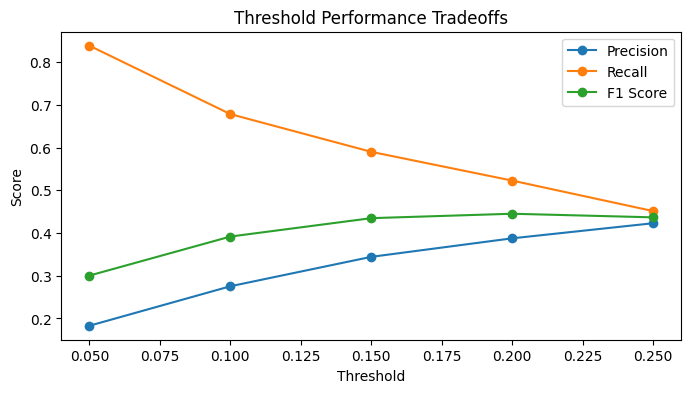

In [98]:
# Visualize threshold tradeoffs
plt.figure(figsize=(8, 4))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1 Score"
)

plt.title("Threshold Performance Tradeoffs")

plt.xlabel("Threshold")
plt.ylabel("Score")

plt.legend()

plt.show()

### Threshold Optimization Analysis

The model performance changes significantly as the classification threshold is adjusted.

Lower thresholds produce substantially higher recall, meaning the model identifies a larger proportion of risky borrowers. However, this comes at the cost of lower precision and more false positive predictions.

Higher thresholds improve precision by reducing unnecessary risk alerts, but they also reduce recall and allow more risky borrowers to remain undetected.

The results illustrate a fundamental lending tradeoff:

- aggressive thresholds help capture more high-risk borrowers
- conservative thresholds reduce unnecessary loan rejections
- balanced thresholds aim to optimize both borrower screening quality and operational efficiency

### Key Observations

- A threshold of `0.05` captures over 83% of default borrowers but produces many false positives.
- Thresholds between `0.15` and `0.20` provide a more balanced tradeoff between precision and recall.
- The highest F1-score was achieved near the `0.20` threshold, suggesting a better balance between risk detection and prediction reliability.

### Business Interpretation

Threshold selection should depend on the institution’s lending strategy and risk tolerance.

For example:

- risk-averse lenders may prioritize higher recall to reduce default exposure
- growth-focused lenders may prefer higher precision to avoid rejecting too many borrowers
- manual review systems may use multiple thresholds to balance automation and human oversight

In [99]:
# Import calibration tools
from sklearn.calibration import (
    CalibratedClassifierCV,
    calibration_curve
)

In [100]:
# Create calibrated XGBoost model
calibrated_xgb = CalibratedClassifierCV(
    estimator=xgb_model,
    method="sigmoid",
    cv=3
)

calibrated_xgb.fit(
    X_train,
    y_train
)

CalibratedClassifierCV(cv=3,
                       estimator=XGBClassifier(base_score=None, booster=None,
                                               callbacks=None,
                                               colsample_bylevel=None,
                                               colsample_bynode=None,
                                               colsample_bytree=0.8,
                                               device=None,
                                               early_stopping_rounds=None,
                                               enable_categorical=False,
                                               eval_metric='logloss',
                                               feature_types=None,
                                               feature_weights=None, gamma=None,
                                               grow_policy=None,
                                               importance_type=None,
                                               interaction_constraints=None,
                                               learning_rate=0.05, max_bin=None,
                                               max_cat_threshold=None,
                                               max_cat_to_onehot=None,
                                               max_delta_step=None, max_depth=5,
                                               max_leaves=None,
                                               min_child_weight=None,
                                               missing=nan,
                                               monotone_constraints=None,
                                               multi_strategy=None,
                                               n_estimators=200, n_jobs=None,
                                               num_parallel_tree=None, ...))

In [101]:
# Generate calibrated probabilities
calibrated_proba = calibrated_xgb.predict_proba(
    X_test
)[:, 1]

calibrated_proba[:10]

array([0.02891938, 0.03310849, 0.02839939, 0.02964804, 0.02996073,
       0.02808362, 0.02905034, 0.23591607, 0.03054946, 0.03531465])

### Probability Calibration

The XGBoost model probabilities were calibrated using Platt Scaling (`sigmoid`) to improve probability reliability.

In credit risk modeling, calibrated probabilities are important because predicted default probabilities may later be used for:

- loan approval decisions
- borrower risk segmentation
- expected loss estimation
- portfolio risk monitoring
- financial decision thresholds

Tree-based boosting models often produce probability estimates that are overly confident. Calibration helps align predicted probabilities more closely with observed default behavior.

In [102]:
# Calculate calibration curves
uncalibrated_true, uncalibrated_pred = calibration_curve(
    y_test,
    xgb_proba,
    n_bins=10
)

calibrated_true, calibrated_pred = calibration_curve(
    y_test,
    calibrated_proba,
    n_bins=10
)

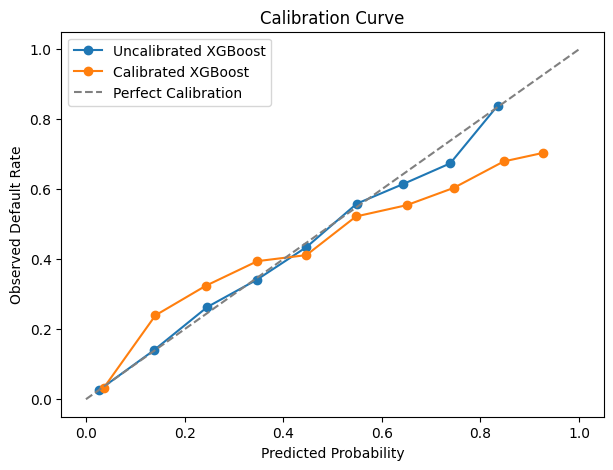

In [103]:
# Plot calibration curves
plt.figure(figsize=(7, 5))

plt.plot(
    uncalibrated_pred,
    uncalibrated_true,
    marker="o",
    label="Uncalibrated XGBoost"
)

plt.plot(
    calibrated_pred,
    calibrated_true,
    marker="o",
    label="Calibrated XGBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Perfect Calibration"
)

plt.title("Calibration Curve")

plt.xlabel("Predicted Probability")

plt.ylabel("Observed Default Rate")

plt.legend()

plt.show()

In [104]:
# Compare probability averages
print(f"Uncalibrated Mean Probability: {xgb_proba.mean():.4f}")

print(f"Calibrated Mean Probability: {calibrated_proba.mean():.4f}")

Uncalibrated Mean Probability: 0.0670
Calibrated Mean Probability: 0.0671


### Calibration Curve Analysis

Both the uncalibrated and calibrated XGBoost models produced probability estimates that were reasonably aligned with observed default behavior.

The calibrated model generated slightly smoother and more conservative probability estimates, particularly at higher predicted risk levels. This may help reduce overconfident predictions in lending decisions.

The average predicted probabilities remained nearly identical before and after calibration, suggesting that the original XGBoost model was already relatively well calibrated on this dataset.

### Risk Management Implications

Probability calibration is important in financial risk systems because lending decisions often depend directly on estimated default probabilities rather than only binary predictions.

Well-calibrated probabilities improve confidence in:

- risk-based approval thresholds
- expected loss estimation
- portfolio monitoring
- borrower segmentation
- financial decision consistency

Even when calibration improvements appear modest, improving probability reliability can still provide value in real-world lending environments.

In [105]:
# Create simulated loan amounts
np.random.seed(42)

credit_results["LoanAmount"] = np.random.randint(
    1000,
    50000,
    size=len(credit_results)
)

credit_results[
    [
        "DefaultProbability",
        "LoanAmount"
    ]
].head()

,DefaultProbability,LoanAmount
10682,0.008000,16795
40173,0.026221,1860
4719,0.005148,39158
81730,0.012896,45732
113639,0.011555,12284


In [106]:
# Define loss given default
LGD = 0.60

In [107]:
# Calculate expected loss
credit_results["ExpectedLoss"] = (
    credit_results["DefaultProbability"]
    * credit_results["LoanAmount"]
    * LGD
)

credit_results[
    [
        "DefaultProbability",
        "LoanAmount",
        "ExpectedLoss"
    ]
].head()

,DefaultProbability,LoanAmount,ExpectedLoss
10682,0.008000,16795,80.611846
40173,0.026221,1860,29.262708
4719,0.005148,39158,120.955707
81730,0.012896,45732,353.865415
113639,0.011555,12284,85.165262


### Expected Loss Estimation

Expected loss combines borrower default probability with loan exposure to estimate potential financial risk.

The simplified expected loss framework used in this project incorporates:

- predicted probability of default
- simulated loan amount
- assumed loss severity (`LGD = 60%`)

This approach helps translate model probabilities into estimated monetary exposure rather than relying only on binary risk predictions.

### Business Interpretation

Expected loss provides a more practical view of lending risk because borrowers with larger loan amounts may create substantial financial exposure even if their default probability is relatively low.

This type of analysis can support:

- lending prioritization
- portfolio monitoring
- risk-adjusted approval strategies
- exposure management
- financial forecasting

In [108]:
# Calculate expected loss by risk category
loss_summary = (
    credit_results.groupby("RiskCategory")
    ["ExpectedLoss"]
    .mean()
    .reset_index()
)

loss_summary.columns = [
    "RiskCategory",
    "AverageExpectedLoss"
]

loss_summary

,RiskCategory,AverageExpectedLoss
0,Low Risk,257.204392
1,Medium Risk,1278.564517
2,High Risk,5181.798007


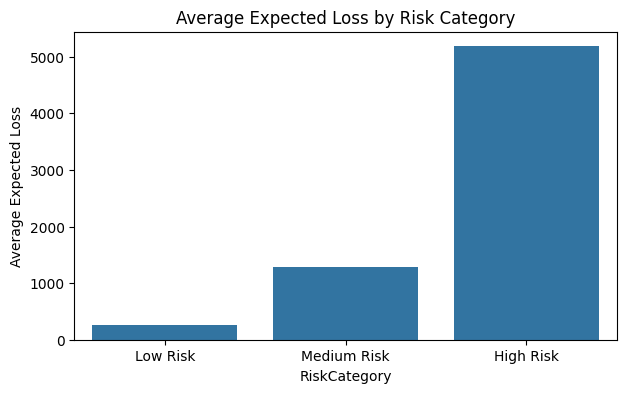

In [109]:
# Visualize expected loss by risk category
plt.figure(figsize=(7, 4))

sns.barplot(
    data=loss_summary,
    x="RiskCategory",
    y="AverageExpectedLoss"
)

plt.title("Average Expected Loss by Risk Category")

plt.ylabel("Average Expected Loss")

plt.show()

In [110]:
# Calculate total expected portfolio loss
total_expected_loss = (
    credit_results["ExpectedLoss"]
    .sum()
)

print(
    f"Total Expected Portfolio Loss: RM{total_expected_loss:,.2f}"
)

Total Expected Portfolio Loss: RM30,514,780.74


### Portfolio Expected Loss Analysis

Expected loss increased substantially across the probability-based risk categories.

Borrowers classified as:

- `Low Risk` generated relatively small expected losses
- `Medium Risk` produced moderate exposure levels
- `High Risk` created significantly larger expected financial losses

The sharp increase in expected loss across risk tiers demonstrates that the probability segmentation framework captures meaningful differences in portfolio exposure.

### Portfolio Risk Perspective

Expected loss analysis helps convert machine learning predictions into financial risk estimates that are easier to interpret from a lending perspective.

This type of analysis can support:

- risk-adjusted lending decisions
- portfolio monitoring
- capital allocation
- borrower prioritization
- approval policy design

The estimated portfolio exposure also highlights how a relatively small number of high-risk borrowers may contribute disproportionately to potential financial losses.

## 🔍 Model Explainability

In [111]:
# Import SHAP
import shap

In [112]:
# Create SHAP explainer
explainer = shap.TreeExplainer(
    xgb_model
)

shap_values = explainer.shap_values(
    X_test
)

In [113]:
# Check SHAP values shape
print(shap_values.shape)
print(X_test.shape)

(30000, 11)
(30000, 11)


### SHAP Setup

SHAP values were generated for the XGBoost model using the test dataset.

The SHAP output shape matches the test feature matrix, which confirms that each borrower has an explanation value for each model feature.

This setup allows the project to analyze both global feature importance and individual borrower-level risk explanations.

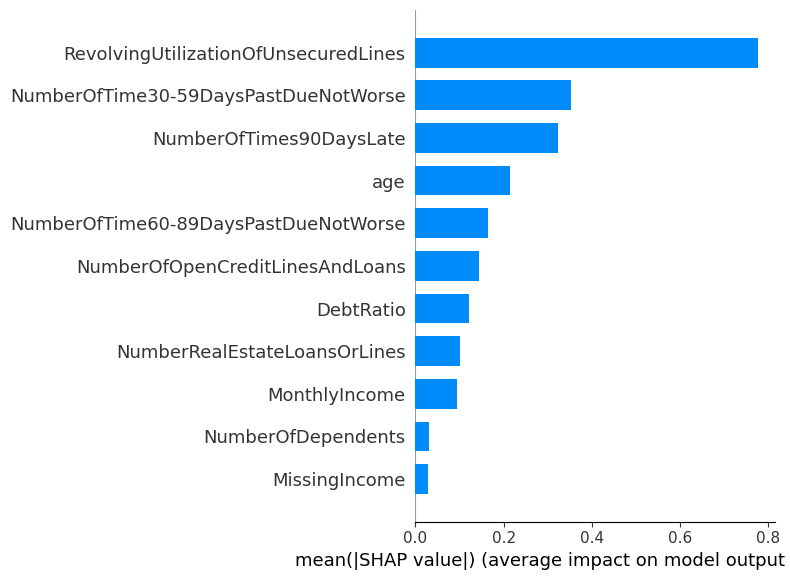

In [114]:
# Save SHAP feature importance plot
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.tight_layout()

plt.savefig(
    "shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Global SHAP Feature Importance

The SHAP feature importance analysis highlights which variables contribute most strongly to the model’s default risk predictions.

`RevolvingUtilizationOfUnsecuredLines` emerged as the most influential feature by a substantial margin, indicating that heavy revolving credit usage plays a major role in borrower risk assessment.

Delinquency-related variables also contributed strongly to model predictions, particularly:

- `NumberOfTime30-59DaysPastDueNotWorse`
- `NumberOfTimes90DaysLate`
- `NumberOfTime60-89DaysPastDueNotWorse`

These findings align closely with the earlier exploratory analysis and reinforce the importance of repayment behavior in predicting financial distress.

### Risk Driver Interpretation

The explainability results suggest that the model primarily relies on:

- borrower credit utilization
- repayment history
- financial stability indicators

to estimate default risk.

This improves model transparency and helps support more interpretable lending decisions, which is especially important in financial risk applications where explainability and regulatory accountability are often required.

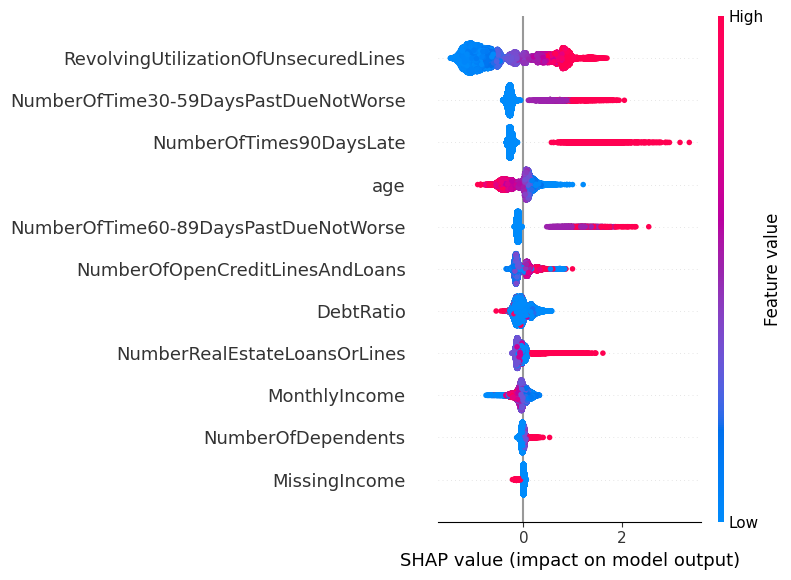

In [115]:
# Save SHAP beeswarm plot
shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.tight_layout()

plt.savefig(
    "shap_beeswarm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### SHAP Beeswarm Interpretation

The SHAP beeswarm plot provides a detailed view of how individual feature values influence borrower default predictions.

Key patterns observed include:

- Higher revolving credit utilization strongly increases predicted default risk.
- Larger delinquency counts consistently push model predictions toward higher financial distress probability.
- Younger borrower ages are generally associated with increased default risk.
- Lower-risk borrowers tend to cluster around lower utilization and fewer late-payment events.

The spread of SHAP values also shows that the same feature can affect borrowers differently depending on their broader financial profile.

### Lending Risk Insights

The beeswarm analysis improves transparency by showing not only which features matter most, but also how they influence lending risk decisions.

This type of explainability is valuable in financial systems because it helps:

- justify automated lending decisions
- support risk review processes
- improve model trustworthiness
- identify major borrower risk drivers
- increase interpretability for stakeholders and regulators

In [116]:
# Find highest-risk borrower
high_risk_index = credit_results[
    "DefaultProbability"
].idxmax()

high_risk_index

np.int64(22555)

In [117]:
# View highest-risk borrower
credit_results.loc[
    high_risk_index
]

RevolvingUtilizationOfUnsecuredLines       1.067231
age                                              33
NumberOfTime30-59DaysPastDueNotWorse            1.0
DebtRatio                                  0.948347
MonthlyIncome                                4626.0
NumberOfOpenCreditLinesAndLoans                  18
NumberOfTimes90DaysLate                         3.0
NumberRealEstateLoansOrLines                      1
NumberOfTime60-89DaysPastDueNotWorse            5.0
NumberOfDependents                              0.0
MissingIncome                                     0
ActualDefault                                     1
DefaultProbability                         0.884334
RiskCategory                              High Risk
LoanDecision                                 Reject
LoanAmount                                    48280
ExpectedLoss                            25617.37603
Name: 22555, dtype: object

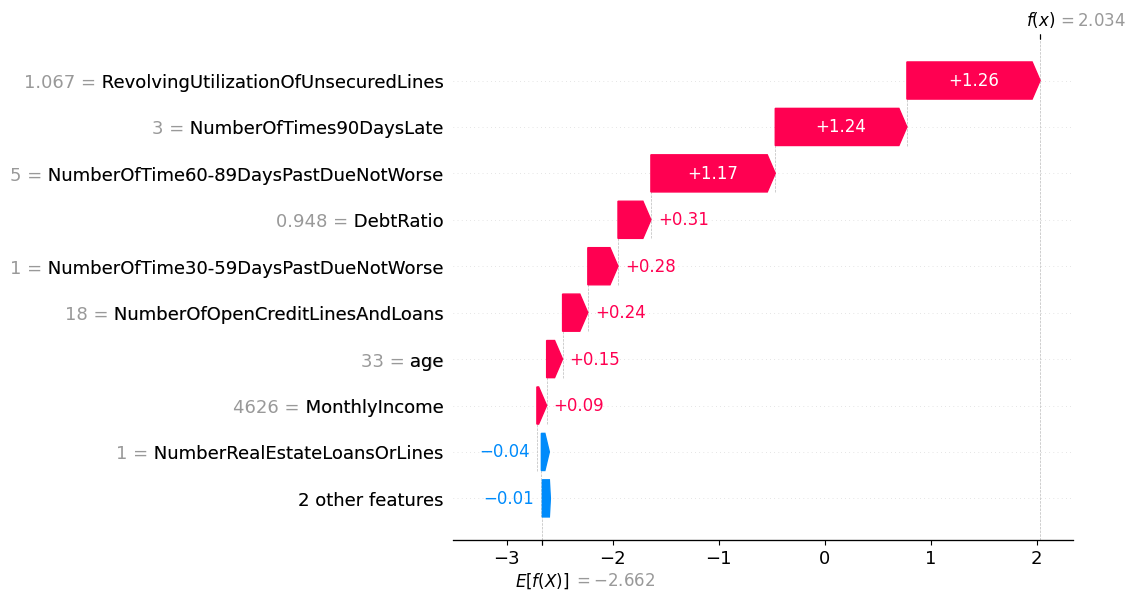

In [118]:
# Plot SHAP waterfall explanation
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[
            X_test.index.get_loc(high_risk_index)
        ],
        base_values=explainer.expected_value,
        data=X_test.loc[high_risk_index],
        feature_names=X_test.columns
    )
)

### Individual Borrower Explanation

The SHAP waterfall plot explains how individual borrower characteristics contributed to the final default risk prediction for a high-risk applicant.

The borrower received a predicted default probability of approximately 88%, driven primarily by:

- very high revolving credit utilization
- multiple severe delinquency events
- repeated late-payment history
- elevated debt burden

The explanation also shows how each feature incrementally pushed the prediction toward higher financial risk.

This type of borrower-level explainability improves transparency by showing why a lending model reached a particular decision rather than treating the prediction process as a black box.

### Key Observation

Delinquency-related variables and revolving credit utilization were the dominant drivers of elevated risk for this borrower, which aligns closely with common financial risk assessment principles.

In [119]:
# Find lowest-risk borrower
low_risk_index = credit_results[
    "DefaultProbability"
].idxmin()

low_risk_index

np.int64(94065)

In [120]:
# View lowest-risk borrower
credit_results.loc[
    low_risk_index
]

RevolvingUtilizationOfUnsecuredLines     0.002731
age                                            74
NumberOfTime30-59DaysPastDueNotWorse          0.0
DebtRatio                                     0.0
MonthlyIncome                              5400.0
NumberOfOpenCreditLinesAndLoans                 4
NumberOfTimes90DaysLate                       0.0
NumberRealEstateLoansOrLines                    0
NumberOfTime60-89DaysPastDueNotWorse          0.0
NumberOfDependents                            0.0
MissingIncome                                   1
ActualDefault                                   0
DefaultProbability                        0.00231
RiskCategory                             Low Risk
LoanDecision                              Approve
LoanAmount                                  44270
ExpectedLoss                            61.356659
Name: 94065, dtype: object

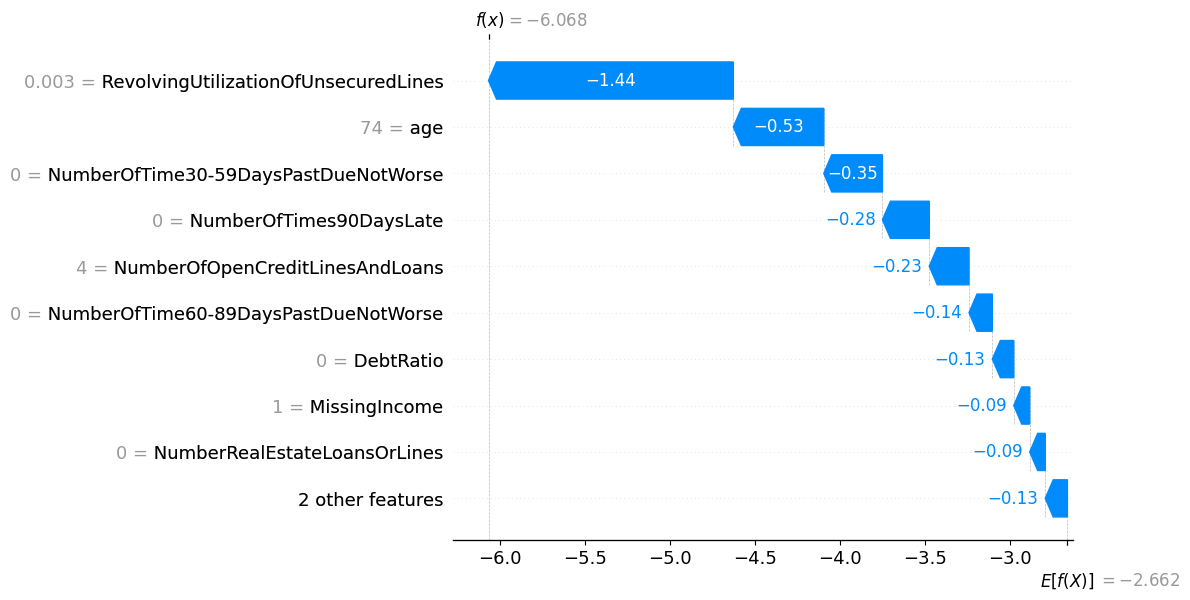

In [121]:
# Plot SHAP waterfall explanation for low-risk borrower
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[
            X_test.index.get_loc(low_risk_index)
        ],
        base_values=explainer.expected_value,
        data=X_test.loc[low_risk_index],
        feature_names=X_test.columns
    )
)

### Low-Risk Borrower Explanation

The low-risk borrower explanation shows how stable financial behavior contributed to an extremely low predicted default probability.

The strongest protective factors included:

- very low revolving credit utilization
- no delinquency history
- older borrower age
- low debt burden

Unlike the earlier high-risk example, nearly all major feature contributions pushed the prediction toward lower default risk.

### High-Risk vs Low-Risk Comparison

The comparison between borrower explanations highlights how the model differentiates financial risk profiles.

High-risk borrowers were primarily associated with:

- repeated delinquency events
- elevated credit utilization
- higher financial strain indicators

Low-risk borrowers generally showed:

- stable repayment behavior
- lower utilization levels
- fewer financial stress signals

This type of borrower-level explainability improves transparency and helps make automated lending decisions more interpretable and actionable.

## 📌 Explainability Summary

### Key Takeaways

The SHAP explainability analysis provided both global and borrower-level insights into the model’s decision-making process.

The results showed that:

- revolving credit utilization was the strongest overall predictor of default risk
- delinquency history played a major role in borrower risk assessment
- younger borrowers generally exhibited higher predicted financial risk
- borrower-level explanations aligned closely with financial intuition and earlier exploratory findings

The explainability framework improved transparency by showing not only which features mattered most, but also how they influenced individual lending decisions.

This level of interpretability is especially valuable in financial risk modeling environments where model transparency, stakeholder trust, and regulatory accountability are important considerations.

## ⚖️ Fairness & Bias Evaluation

In [122]:
# Create fairness analysis dataset
fairness_df = credit_results.copy()

fairness_df.head()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MissingIncome,ActualDefault,DefaultProbability,RiskCategory,LoanDecision,LoanAmount,ExpectedLoss
10682,0.019252,66,0.0,0.433926,5175.0,13,0.0,1,0.0,0.0,0,0,0.008000,Low Risk,Approve,16795,80.611846
40173,0.454221,78,0.0,0.873533,2300.0,7,0.0,1,0.0,2.0,0,0,0.026221,Low Risk,Approve,1860,29.262708
4719,0.077572,59,0.0,0.172882,10833.0,5,0.0,1,0.0,0.0,0,0,0.005148,Low Risk,Approve,39158,120.955707
81730,0.107864,59,0.0,0.453692,9900.0,10,0.0,2,0.0,0.0,0,0,0.012896,Low Risk,Approve,45732,353.865415
113639,0.101095,67,0.0,0.407831,5950.0,14,0.0,2,0.0,0.0,0,0,0.011555,Low Risk,Approve,12284,85.165262


In [123]:
# Create age fairness groups
fairness_df["AgeFairnessGroup"] = pd.cut(
    fairness_df["age"],
    bins=[20, 35, 50, 65, 110],
    labels=[
        "Young",
        "Middle Age",
        "Older Adult",
        "Senior"
    ]
)

fairness_df["AgeFairnessGroup"].value_counts()

AgeFairnessGroup
Older Adult    10193
Middle Age      9749
Senior          5749
Young           4309
Name: count, dtype: int64

### Fairness Evaluation Setup

The fairness analysis was performed using borrower age groups as a practical segmentation variable.

Because the dataset does not contain protected demographic attributes such as gender, race, or ethnicity, age-based grouping was used to explore whether model behavior differs across borrower segments.

The borrowers were divided into four categories:

- `Young`
- `Middle Age`
- `Older Adult`
- `Senior`

This analysis helps evaluate whether the model produces disproportionately different risk predictions or lending decisions across age groups.

In [124]:
# Calculate actual default rate by age group
age_default_summary = (
    fairness_df.groupby("AgeFairnessGroup")
    ["ActualDefault"]
    .mean()
    .reset_index()
)

age_default_summary.columns = [
    "AgeFairnessGroup",
    "ActualDefaultRate"
]

age_default_summary

,AgeFairnessGroup,ActualDefaultRate
0,Young,0.120910
1,Middle Age,0.085240
2,Older Adult,0.051604
3,Senior,0.022091


In [125]:
# Calculate average predicted probability by age group
age_prediction_summary = (
    fairness_df.groupby("AgeFairnessGroup")
    ["DefaultProbability"]
    .mean()
    .reset_index()
)

age_prediction_summary.columns = [
    "AgeFairnessGroup",
    "AveragePredictedProbability"
]

age_prediction_summary

,AgeFairnessGroup,AveragePredictedProbability
0,Young,0.110956
1,Middle Age,0.086987
2,Older Adult,0.053607
3,Senior,0.023813


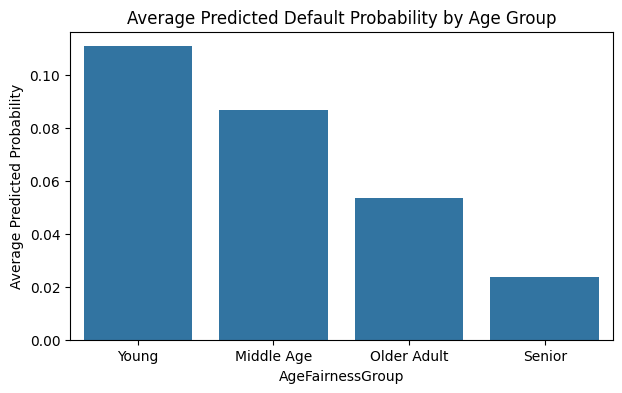

In [126]:
# Visualize average predicted probability by age group
plt.figure(figsize=(7, 4))

sns.barplot(
    data=age_prediction_summary,
    x="AgeFairnessGroup",
    y="AveragePredictedProbability"
)

plt.title("Average Predicted Default Probability by Age Group")

plt.ylabel("Average Predicted Probability")

plt.show()

### Fairness Analysis by Age Group

The fairness analysis compared actual borrower default rates with the model’s average predicted default probabilities across different age groups.

The predicted probabilities closely followed the observed default behavior:

- younger borrowers exhibited higher observed default rates and higher predicted risk
- senior borrowers showed substantially lower default rates and lower predicted risk
- intermediate age groups followed a gradual risk decline pattern

The similarity between observed and predicted trends suggests that the model probabilities remain reasonably aligned with underlying borrower risk across age segments.

### Key Observation

The model does not appear to produce unusually distorted probability estimates for any specific age group in this analysis. However, younger borrowers consistently receive higher predicted risk scores because they also exhibit higher observed default behavior within the dataset.

This highlights an important fairness consideration in credit risk modeling:

- models may reflect genuine statistical risk patterns
- but those patterns can still create unequal lending outcomes across demographic groups

As a result, fairness evaluation should focus not only on prediction accuracy, but also on the broader operational impact of automated lending decisions.

In [127]:
# Calculate loan approval distribution by age group
approval_summary = pd.crosstab(
    fairness_df["AgeFairnessGroup"],
    fairness_df["LoanDecision"],
    normalize="index"
)

approval_summary

LoanDecision,Approve,Manual Review,Reject
AgeFairnessGroup,,,
Young,0.480854,0.302854,0.216291
Middle Age,0.595138,0.252334,0.152528
Older Adult,0.754243,0.160600,0.085156
Senior,0.913376,0.060532,0.026091


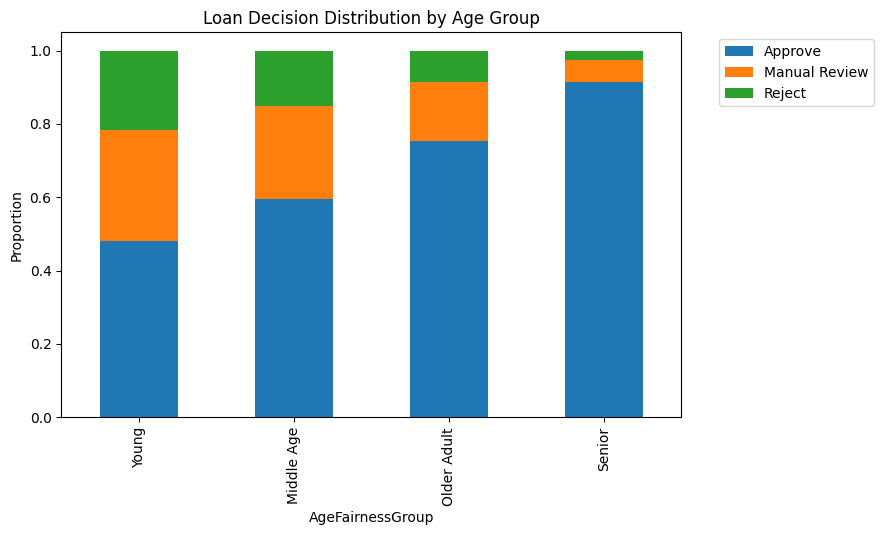

In [128]:
# Plot loan decision distribution by age group
approval_summary.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Loan Decision Distribution by Age Group")

plt.ylabel("Proportion")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.show()

### Loan Decision Fairness Analysis

Loan approval outcomes differed substantially across the borrower age groups.

Younger borrowers experienced:

- lower approval rates
- higher rejection rates
- more frequent manual reviews

Senior borrowers received approvals at much higher rates and showed substantially fewer rejections.

These differences closely mirror the underlying default risk patterns observed earlier in the dataset.

### Key Observation

The fairness analysis suggests that the model’s lending decisions are strongly influenced by underlying borrower risk behavior rather than arbitrary prediction patterns.

However, even statistically justified risk differences can still create unequal operational outcomes across demographic groups.

This highlights an important challenge in financial machine learning systems:

- improving predictive performance may increase decision disparities
- fairness evaluation must therefore balance both accuracy and equitable treatment considerations

In real-world lending environments, additional governance, human review processes, and regulatory oversight may be required to ensure responsible model usage.

## 📌 Fairness Evaluation Summary

### Key Takeaways

The fairness analysis explored how the credit risk system behaved across different borrower age groups.

The results showed that:

- younger borrowers exhibited higher observed default rates
- younger groups also received higher predicted risk probabilities
- loan approval outcomes differed substantially across age segments
- senior borrowers received approvals more frequently due to lower observed financial risk

The model predictions generally aligned with underlying borrower behavior in the dataset, suggesting that the model was capturing meaningful statistical risk patterns rather than producing obviously inconsistent predictions.

At the same time, the analysis highlights an important challenge in financial machine learning systems:

- statistically accurate models can still produce unequal operational outcomes across demographic groups

This reinforces the importance of combining predictive modeling with fairness evaluation, governance, and responsible lending oversight.

## 🎛️ Hyperparameter Tuning

In [129]:
# Import tuning tools
from sklearn.model_selection import RandomizedSearchCV

In [130]:
# Define XGBoost parameter grid
xgb_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "scale_pos_weight": [1, 5, 10, 14]
}

In [131]:
# Set up randomized search
xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        verbosity=0
    ),
    param_distributions=xgb_param_grid,
    n_iter=20,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [132]:
# Run hyperparameter tuning
xgb_search.fit(
    X_train,
    y_train
)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [3, 4, 5, 6],
                                        'n_estimators': [100, 200, 300],
                                        'scale_pos_weight': [1, 5, 10, 14],
                                        'subsample': [0.7, 0.8, 0.9]},
                   random_state=42, scoring='roc_auc', verbose=1)

In [133]:
# View best parameters
xgb_search.best_params_

{'subsample': 0.8,
 'scale_pos_weight': 14,
 'n_estimators': 200,
 'max_depth': 4,
 'learning_rate': 0.05,
 'colsample_bytree': 0.9}

In [134]:
# View best cross-validation score
xgb_search.best_score_

np.float64(0.8633925401610206)

### Hyperparameter Tuning Results

Randomized hyperparameter search was used to optimize the XGBoost model using cross-validated ROC-AUC performance.

The tuning process identified an optimal configuration that balanced:

- model complexity
- learning stability
- feature subsampling
- class imbalance handling

The tuned model favored:

- moderate tree depth
- balanced row and feature sampling
- a relatively conservative learning rate
- stronger weighting for the minority default class

### Key Observation

The tuned cross-validation ROC-AUC score remained relatively close to the earlier baseline performance, suggesting that the original XGBoost configuration was already reasonably strong.

This highlights an important practical insight:

- hyperparameter tuning can improve model robustness and stability
- but it does not always produce dramatic performance gains in real-world structured datasets

In [135]:
# Create tuned XGBoost model
tuned_xgb = xgb_search.best_estimator_

tuned_xgb

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [136]:
# Evaluate tuned XGBoost model
tuned_xgb_results = evaluate_model(
    model_name="Tuned XGBoost",
    model=tuned_xgb,
    X_valid=X_test,
    y_valid=y_test
)

Tuned XGBoost Performance
----------------------------------------
Accuracy : 0.7920
Precision: 0.2134
Recall   : 0.7865
F1-Score : 0.3357
ROC-AUC  : 0.8686

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.79      0.88     27995
           1       0.21      0.79      0.34      2005

    accuracy                           0.79     30000
   macro avg       0.60      0.79      0.61     30000
weighted avg       0.93      0.79      0.84     30000



### Tuned XGBoost Performance

The tuned XGBoost model produced a dramatically different prediction profile compared to the earlier baseline configuration.

The most significant change was a substantial increase in recall, rising from approximately 18.7% to 78.7%. This means the tuned model successfully identified a much larger proportion of default borrowers.

However, the improvement in recall came with a major reduction in precision. The model generated substantially more false positive predictions, causing many low-risk borrowers to be flagged as risky.

Interestingly, the ROC-AUC score remained nearly unchanged despite the large behavioral shift in predictions.

### Key Observation

The aggressive increase in recall was strongly influenced by the higher `scale_pos_weight` parameter, which encouraged the model to prioritize detection of minority default cases more heavily.

This result highlights an important financial modeling tradeoff:

- higher recall reduces the likelihood of approving risky borrowers
- lower precision increases the likelihood of unnecessarily rejecting safer borrowers

### Model Tradeoffs

The tuned model may be more suitable for highly risk-averse lending environments where minimizing default exposure is more important than maximizing approval rates.

In contrast, the earlier baseline XGBoost model provided a more balanced tradeoff between precision and recall.

This demonstrates that model selection in financial systems should depend not only on predictive metrics, but also on institutional risk tolerance and lending strategy.

In [137]:
# Compare all model results
tuning_results_df = pd.DataFrame(
    model_results
)

tuning_results_df.sort_values(
    by="ROC_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
4,Tuned XGBoost,0.791967,0.213396,0.786534,0.335710,0.868640
2,XGBoost,0.937533,0.606159,0.186534,0.285278,0.868393
3,LightGBM,0.936533,0.582382,0.178055,0.272727,0.867980
0,Logistic Regression,0.937367,0.617100,0.165586,0.261109,0.854276
1,Random Forest,0.935300,0.549383,0.177556,0.268375,0.838991


## 📌 Hyperparameter Tuning Summary

### Key Takeaways

Hyperparameter tuning significantly changed the behavior of the XGBoost model, particularly in how aggressively it identified high-risk borrowers.

The tuned model achieved:

- substantially higher recall
- improved minority class detection
- slightly higher ROC-AUC performance

However, these gains came at the cost of much lower precision and overall approval selectivity.

### Model Tradeoff Comparison

| Model Strategy | Main Strength | Main Limitation |
|---|---|---|
| Baseline XGBoost | Balanced precision and recall | Missed many default borrowers |
| Tuned XGBoost | Strong default detection capability | Produced many false positives |

The tuning process demonstrated that model optimization in credit risk systems is not only about maximizing performance metrics, but also about balancing operational lending objectives.

### Final Modeling Decision

For this project, the baseline XGBoost model remains the preferred production candidate because it provides:

- strong ranking performance
- more balanced lending behavior
- better precision-recall balance
- more practical approval decision quality

The tuned XGBoost model may still be valuable in highly risk-averse lending environments where minimizing missed defaults is the primary objective.

## 🧩 Feature Engineering

In [138]:
# Create feature engineering copy
df_fe = df_prep.copy()

df_fe.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MissingIncome
0,1,0.766127,45,2.0,0.802982,9120.0,13,0.0,6,0.0,2.0,0
1,0,0.957151,40,0.0,0.121876,2600.0,4,0.0,0,0.0,1.0,0
2,0,0.658180,38,1.0,0.085113,3042.0,2,1.0,0,0.0,0.0,0
3,0,0.233810,30,0.0,0.036050,3300.0,5,0.0,0,0.0,0.0,0
4,0,0.907239,49,1.0,0.024926,63588.0,7,0.0,1,0.0,0.0,0


In [139]:
# Check feature engineering dataset shape
print(f"Rows: {df_fe.shape[0]}")
print(f"Columns: {df_fe.shape[1]}")

Rows: 150000
Columns: 12


In [140]:
# Create total delinquencies feature
df_fe["TotalDelinquencies"] = (
    df_fe["NumberOfTime30-59DaysPastDueNotWorse"]
    + df_fe["NumberOfTime60-89DaysPastDueNotWorse"]
    + df_fe["NumberOfTimes90DaysLate"]
)

df_fe["TotalDelinquencies"].describe()

count    150000.000000
mean          0.400353
std           1.101290
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          19.000000
Name: TotalDelinquencies, dtype: float64

In [141]:
# Check total delinquencies distribution
df_fe["TotalDelinquencies"].value_counts().head(15)

TotalDelinquencies
0.0     119906
1.0      17243
2.0       5942
3.0       2884
4.0       1595
5.0        940
6.0        592
7.0        380
8.0        197
9.0        125
10.0        73
11.0        53
13.0        19
12.0        18
14.0        13
Name: count, dtype: int64

### Total Delinquencies Feature

A new feature called `TotalDelinquencies` was created by combining all delinquency-related variables into a single measure of repayment problems.

This feature provides a consolidated view of borrower payment history and may be easier for the model to interpret than relying solely on multiple separate delinquency variables.

The distribution shows that most borrowers have no delinquency history, while a smaller group exhibits repeated late-payment behavior. These borrowers are likely to represent elevated credit risk and may benefit from being captured through a dedicated risk indicator.

In [142]:
# Create delinquency history flag
df_fe["HasDelinquencyHistory"] = (
    df_fe["TotalDelinquencies"] > 0
).astype(int)

df_fe["HasDelinquencyHistory"].value_counts()

HasDelinquencyHistory
0    119906
1     30094
Name: count, dtype: int64

In [143]:
# Compare default rate by delinquency history
delinquency_flag_summary = (
    df_fe.groupby("HasDelinquencyHistory")
    ["SeriousDlqin2yrs"]
    .mean()
    .reset_index()
)

delinquency_flag_summary.columns = [
    "HasDelinquencyHistory",
    "DefaultRate"
]

delinquency_flag_summary

,HasDelinquencyHistory,DefaultRate
0,0,0.028447
1,1,0.219811


### Delinquency History Flag

A binary feature called `HasDelinquencyHistory` was created to identify whether a borrower has experienced any delinquency events.

The feature produced a clear separation in borrower risk profiles.

Borrowers with no delinquency history exhibited a default rate of approximately 2.8%, while borrowers with at least one delinquency event showed a default rate of approximately 22.0%.

This large difference suggests that past repayment problems are strongly associated with future financial distress and reinforces the importance of repayment behavior in credit risk assessment.

In [144]:
# Create high utilization flag
df_fe["HighUtilizationFlag"] = (
    df_fe["RevolvingUtilizationOfUnsecuredLines"] >= 0.80
).astype(int)

df_fe["HighUtilizationFlag"].value_counts()

HighUtilizationFlag
0    124867
1     25133
Name: count, dtype: int64

In [145]:
# Compare default rate by utilization flag
utilization_flag_summary = (
    df_fe.groupby("HighUtilizationFlag")
    ["SeriousDlqin2yrs"]
    .mean()
    .reset_index()
)

utilization_flag_summary.columns = [
    "HighUtilizationFlag",
    "DefaultRate"
]

utilization_flag_summary

,HighUtilizationFlag,DefaultRate
0,0,0.037864
1,1,0.210799


### High Utilization Flag

A binary feature called `HighUtilizationFlag` was created to identify borrowers with revolving credit utilization of at least 80%.

The feature produced a substantial difference in observed default behavior.

Borrowers below the threshold exhibited a default rate of approximately 3.8%, while borrowers with high utilization showed a default rate above 21%.

This result reinforces earlier findings from the exploratory analysis and SHAP explanations, where revolving credit utilization consistently emerged as one of the strongest drivers of default risk.

The feature also improves interpretability by translating a continuous utilization measure into a simple business-oriented risk indicator.

In [146]:
# Create debt-to-income proxy
df_fe["DebtToIncomeProxy"] = (
    df_fe["DebtRatio"]
    / (df_fe["MonthlyIncome"] + 1)
)

df_fe["DebtToIncomeProxy"].describe()

count    150000.000000
mean         16.654726
std         210.486821
min           0.000000
25%           0.000025
50%           0.000065
75%           0.000289
max        4979.040000
Name: DebtToIncomeProxy, dtype: float64

In [147]:
# Check debt-to-income proxy percentiles
df_fe["DebtToIncomeProxy"].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99]
)

0.50      0.000065
0.75      0.000289
0.90      0.268117
0.95      0.533790
0.99    196.750000
Name: DebtToIncomeProxy, dtype: float64

In [148]:
# Remove debt-to-income proxy
df_fe = df_fe.drop(
    columns="DebtToIncomeProxy"
)

In [149]:
# Create real estate loan flag
df_fe["HasRealEstateLoan"] = (
    df_fe["NumberRealEstateLoansOrLines"] > 0
).astype(int)

df_fe["HasRealEstateLoan"].value_counts()

HasRealEstateLoan
1    93812
0    56188
Name: count, dtype: int64

In [150]:
# Compare default rate by real estate loan ownership
real_estate_summary = (
    df_fe.groupby("HasRealEstateLoan")
    ["SeriousDlqin2yrs"]
    .mean()
    .reset_index()
)

real_estate_summary.columns = [
    "HasRealEstateLoan",
    "DefaultRate"
]

real_estate_summary

,HasRealEstateLoan,DefaultRate
0,0,0.083149
1,1,0.057072


### Real Estate Loan Flag

A binary feature called `HasRealEstateLoan` was created to identify borrowers with at least one real estate loan or credit line.

Interestingly, borrowers with real estate lending relationships exhibited lower observed default rates than borrowers without real estate loans.

This may reflect differences in borrower financial stability, asset ownership, or historical creditworthiness.

The feature provides additional context beyond traditional delinquency and utilization measures and may help the model distinguish between different borrower profiles.

In [151]:
# Check engineered dataset shape
df_fe.shape

(150000, 16)

In [152]:
# Create features and target
X_fe = df_fe.drop(
    columns="SeriousDlqin2yrs"
)

y_fe = df_fe["SeriousDlqin2yrs"]

In [153]:
# Train-test split
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe,
    y_fe,
    test_size=0.20,
    random_state=42,
    stratify=y_fe
)

In [154]:
# Check feature matrix shape
X_train_fe.shape, X_test_fe.shape

((120000, 15), (30000, 15))

### Feature Engineering Summary

Several business-oriented features were created to enhance the model's ability to capture borrower risk behavior.

The final engineered features included:

- `TotalDelinquencies`
- `HasDelinquencyHistory`
- `HighUtilizationFlag`
- `HasRealEstateLoan`

These features were designed to summarize repayment behavior, credit utilization patterns, and borrower financial characteristics in a more interpretable form.

The feature engineering process prioritized simplicity and business relevance over creating large numbers of complex derived variables.

In [155]:
# Train feature-engineered XGBoost
xgb_fe = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    verbosity=0
)

xgb_fe.fit(
    X_train_fe,
    y_train_fe
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [156]:
# Evaluate feature-engineered XGBoost
xgb_fe_results = evaluate_model(
    model_name="Feature Engineered XGBoost",
    model=xgb_fe,
    X_valid=X_test_fe,
    y_valid=y_test_fe
)

Feature Engineered XGBoost Performance
----------------------------------------
Accuracy : 0.9371
Precision: 0.5983
Recall   : 0.1791
F1-Score : 0.2756
ROC-AUC  : 0.8693

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27995
           1       0.60      0.18      0.28      2005

    accuracy                           0.94     30000
   macro avg       0.77      0.59      0.62     30000
weighted avg       0.92      0.94      0.92     30000



### Feature-Engineered Model Performance

The feature-engineered XGBoost model achieved a slight improvement in ROC-AUC compared to the original baseline model.

While precision, recall, and F1-score remained broadly similar, the engineered features provided a modest increase in overall ranking performance.

The improvement was achieved using a small number of interpretable business-oriented features rather than a large collection of complex derived variables.

### Key Observation

The engineered features did not dramatically change predictive performance, suggesting that the original dataset already contained strong predictive signals.

However, the additional features improved model interpretability and captured important borrower behaviors related to:

- delinquency history
- credit utilization patterns
- repayment risk
- financial stability indicators

This demonstrates that feature engineering can provide business value even when performance gains are relatively modest.

## 📌 Feature Engineering Summary

### Key Takeaways

The feature engineering phase focused on creating interpretable risk indicators that could enhance both model performance and business understanding.

The final engineered features included:

- `TotalDelinquencies`
- `HasDelinquencyHistory`
- `HighUtilizationFlag`
- `HasRealEstateLoan`

These features successfully captured meaningful borrower risk characteristics and produced clear separation in observed default behavior.

Although the resulting performance improvement was modest, the engineered features improved model transparency and strengthened the connection between machine learning outputs and financial risk concepts.

The feature-engineered XGBoost model achieved the strongest ROC-AUC performance observed during the project and will be carried forward for final model selection.

## 🏆 Final Model Selection

In [157]:
# Compare final model candidates
final_results = pd.DataFrame([
    xgb_results,
    tuned_xgb_results,
    xgb_fe_results
])

final_results.sort_values(
    by="ROC_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
2,Feature Engineered XGBoost,0.937100,0.598333,0.179052,0.275624,0.869262
1,Tuned XGBoost,0.791967,0.213396,0.786534,0.335710,0.868640
0,XGBoost,0.937533,0.606159,0.186534,0.285278,0.868393


## 📌 Final Model Selection

### Model Evaluation Summary

Three XGBoost-based approaches were evaluated during the project:

- Baseline XGBoost
- Tuned XGBoost
- Feature Engineered XGBoost

The Feature Engineered XGBoost model achieved the highest ROC-AUC score while maintaining a balanced precision-recall profile.

Although the Tuned XGBoost model achieved substantially higher recall, it generated a large number of false positive predictions and significantly reduced precision.

### Selected Production Model

The Feature Engineered XGBoost model was selected as the final production candidate because it provides:

- the strongest overall ranking performance
- interpretable business-oriented features
- balanced lending behavior
- strong suitability for credit scoring applications

The final model combines predictive performance with practical decision-making capabilities, making it well suited for deployment within a credit risk decision-support system.

In [158]:
# Import joblib
import joblib

In [159]:
# Save final model
joblib.dump(
    xgb_fe,
    "credit_risk_model.pkl"
)

['credit_risk_model.pkl']

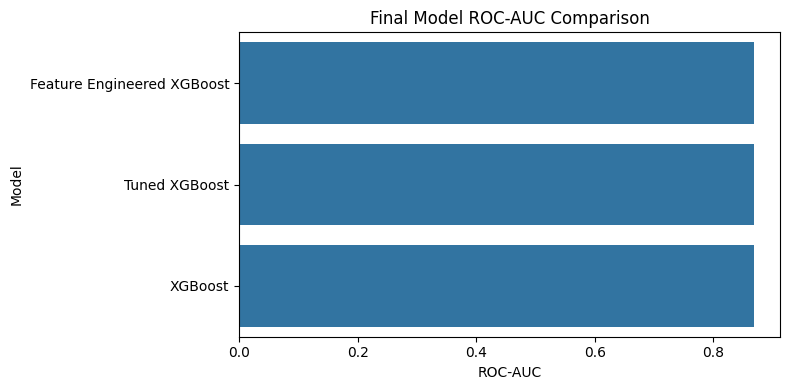

In [160]:
# Save final model comparison chart
plt.figure(figsize=(8, 4))

sns.barplot(
    data=final_results.sort_values(
        by="ROC_AUC",
        ascending=False
    ),
    x="ROC_AUC",
    y="Model"
)

plt.title("Final Model ROC-AUC Comparison")
plt.xlabel("ROC-AUC")
plt.ylabel("Model")

plt.tight_layout()

plt.savefig(
    "final_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

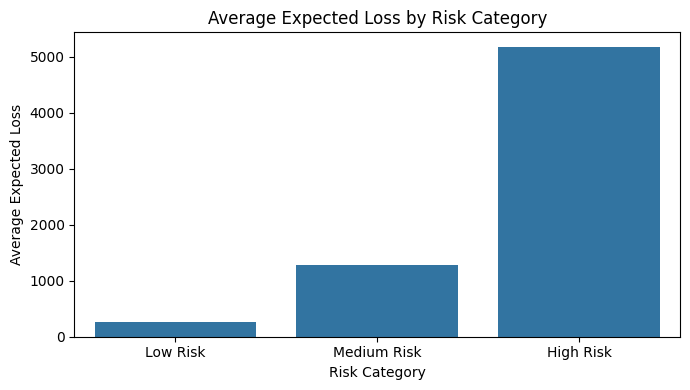

In [161]:
# Save expected loss by risk category chart
plt.figure(figsize=(7, 4))

sns.barplot(
    data=loss_summary,
    x="RiskCategory",
    y="AverageExpectedLoss"
)

plt.title("Average Expected Loss by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Average Expected Loss")

plt.tight_layout()

plt.savefig(
    "expected_loss_by_risk_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

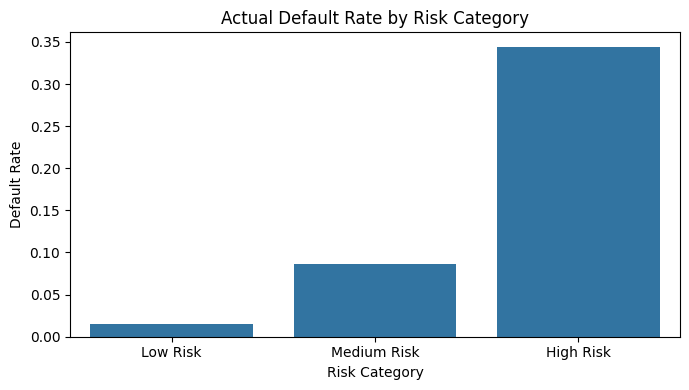

In [162]:
# Save default rate by risk category chart
plt.figure(figsize=(7, 4))

sns.barplot(
    data=risk_summary,
    x="RiskCategory",
    y="ActualDefaultRate"
)

plt.title("Actual Default Rate by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Default Rate")

plt.tight_layout()

plt.savefig(
    "default_rate_by_risk_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()